# EXTERNAL VALIDATION of the 5 Group-Lasso IBD flare models

 
 
- Pipeline = exact mirror of IBD_Flare_Prediction_within6m_Report.ipynb
- applied AS-IS to 'dataset def_select.xlsx'. No refitting, no 70/30 split.
- Outcome : flare = MIAH <= 6.38 (active) OR FC > 250 ug/g,
- paired within 14 days, within 6 months after baseline (PROM_comp_date_1).

 

In [1]:
# Load Required Libraries
# -----------------------
suppressWarnings(
  suppressMessages({
      # Load Required Libraries
    # -----------------------
    library(knitr)
    library(labelled)     # For handling variable labels
    knitr::opts_chunk$set(erro= F, warning= F, message=F, fig.width = 12, collapse = TRUE)
    library(readxl) 

    library(stringr)
    library(lubridate)
    library(pROC)

    library(GGally)
    library(gridExtra)
    library(RColorBrewer)
    library(car)
    library(broom)
    library(kableExtra)
    library(psych)
    library(e1071)  # for skewness() and kurtosis()
    library(MASS)

    library(gglasso)  
    library(tidyverse)
    

  }))

options(repr.plot.width = 12,   repr.plot.height = 5,   repr.plot.res = 150)

In [2]:
# Import Excel files
df <- read_excel("./dataset def_select.xlsx") %>%
  mutate(
    patientIdentifier = as.character(patientIdentifier),
    PROM_comp_date_1  = as.Date(PROM_comp_date_1),
      # Convert birthdate to Date
        birthdate = as.Date(birthdate,  format = "%d-%m-%Y")
  )
cat('RAW ROWS:', nrow(df))

RAW ROWS: 907

# I. Data Preparation

Load & exclude.** Reads dataset _def_select.xlsx_ (907 rows), keeps only CD + UC (**drops 22 IBD U → 885**), then drops UC patients with missing year_diagnosis_uc **→ 835 patients**.



In [3]:
# ----------  EXCLUSIONS ----------
table(df$diagnosis)


Colitis ulcerosa            IBD-U Ziekte van Crohn 
             367               22              518 

In [4]:
df <- df %>%
  filter(diagnosis %in% c("Ziekte van Crohn", "Colitis ulcerosa")) %>%     # drop 22 IBD-U
  rename(DiseaseEntity = diagnosis) %>%                                      # Rename diagnosis → DiseaseEntity.
  mutate(                                                                     # Convert DiseaseEntity to a factor: Ziekte van Crohn → CD and Colitis ulcerosa → UC
    DiseaseEntity = factor(
      DiseaseEntity,
      levels = c("Ziekte van Crohn", "Colitis ulcerosa"),
      labels = c("CD", "UC")
    )
  )

In [5]:
table(df$DiseaseEntity)


 CD  UC 
518 367 

In [6]:
df <- df %>%
  filter(!(DiseaseEntity == "UC" & is.na(year_diagnosis_uc))) # filter out only the UC cases where year_diagnosis_uc is NA:

In [7]:
cat('RAW ROWS:', nrow(df))

RAW ROWS: 835

EXCLUSIONS: after IBD-U drop: 885; after UC-missing-year drop: 835


## I.1 Dates for each of the six windows

Each dataset `df_k` is anchored on its own baseline `PROM_comp_date_k`, with the corresponding MIAH dates `miahcd_date_k` (CD) and `miahcu_date_k` (UC). Observed ranges (min–max) in the validation data:

| Window | Baseline `PROM_comp_date_k` | `miahcd_date_k` (CD) | `miahcu_date_k` (UC) |
|---|---|---|---|
| 1 | 2023‑11‑11 → 2026‑06‑08 | 2023‑11‑11 → 2026‑06‑08 | 2023‑11‑11 → 2025‑06‑24 |
| 2 | 2024‑04‑27 → 2026‑05‑28 | 2023‑11‑14 → 2026‑05‑28 | 2024‑04‑27 → 2026‑05‑21 |
| 3 | 2024‑11‑09 → 2026‑07‑21 | 2024‑11‑09 → 2026‑07‑21 | 2024‑11‑09 → 2026‑06‑01 |
| 4 | 2025‑05‑10 → 2026‑07‑07 | 2025‑05‑10 → 2026‑07‑07 | 2025‑05‑10 → 2026‑06‑05 |
| 5 | 2025‑11‑08 → 2026‑07‑02 | 2025‑11‑08 → 2026‑07‑02 | 2025‑11‑08 → 2026‑06‑22 |
| 6 | 2026‑05‑09 → 2026‑08‑02 | 2026‑05‑09 → 2026‑08‑02 | 2026‑05‑09 → 2026‑07‑04 |

Two observations worth noting for the report:

- **CD MIAH dates coincide with the PROM baseline dates** (a MIAH completion *is* the PROM completion), while **UC MIAH availability is shorter**: e.g. window 1 UC readings stop at 2025‑06‑24, and window 2 UC starts only at 2024‑04‑27 (with a gap until 2026‑05‑21). So UC patients contribute flare detection windows that end earlier than CD patients' — relevant when interpreting the CD/UC split of `df1` results.
- The **6‑month pairing window** means a flare at time point *k* can be triggered by an FC or MIAH reading up to 6 months *after* `PROM_comp_date_k`; windows 5 and 6 (2025‑11‑08 and 2026‑05‑09 baselines) therefore have far less room for such readings before the dataset ends (2026‑08‑02), which is exactly why their event counts collapse to 12 and 2.


In [8]:
print('baseline period')
min(df$baseline); max(df$baseline)

[1] "baseline period"


[1] "2023-11-11 UTC"

[1] "2026-06-08 UTC"

In [9]:
print('birthdate period')
min(df$birthdate); max(df$birthdate)

[1] "birthdate period"


[1] "1936-08-01"

[1] "2024-08-26"

In [10]:
cat('MIAH CD range:')
cat('\n 1:'); min(df$miahcd_date1, na.rm = TRUE) ; max(df$miahcd_date1, na.rm = TRUE)
cat('\n 2:'); min(df$miahcd_date2, na.rm = TRUE) ; max(df$miahcd_date2, na.rm = TRUE)
cat('\n 3:'); min(df$miahcd_date3, na.rm = TRUE) ; max(df$miahcd_date3, na.rm = TRUE)
cat('\n 4:'); min(df$miahcd_date4, na.rm = TRUE) ; max(df$miahcd_date4, na.rm = TRUE)
cat('\n 5:'); min(df$miahcd_date5, na.rm = TRUE) ; max(df$miahcd_date5, na.rm = TRUE)
cat('\n 6:'); min(df$miahcd_date6, na.rm = TRUE) ; max(df$miahcd_date6, na.rm = TRUE)

MIAH CD range:
 1:

[1] "2023-11-11 UTC"

[1] "2026-06-08 UTC"


 2:

[1] "2023-11-14 UTC"

...

[1] "2025-11-08 UTC"

[1] "2026-07-02 UTC"


 6:

[1] "2026-05-09 UTC"

[1] "2026-08-02 UTC"

In [11]:
cat('MIAH UC range:')
cat('\n 1:'); min(df$miahcu_date1, na.rm = TRUE) ; max(df$miahcu_date1, na.rm = TRUE)
cat('\n 2:'); min(df$miahcu_date2, na.rm = TRUE) ; max(df$miahcu_date2, na.rm = TRUE)
cat('\n 3:'); min(df$miahcu_date3, na.rm = TRUE) ; max(df$miahcu_date3, na.rm = TRUE)
cat('\n 4:'); min(df$miahcu_date4, na.rm = TRUE) ; max(df$miahcu_date4, na.rm = TRUE)
cat('\n 5:'); min(df$miahcu_date5, na.rm = TRUE) ; max(df$miahcu_date5, na.rm = TRUE)
cat('\n 6:'); min(df$miahcu_date6, na.rm = TRUE) ; max(df$miahcu_date6, na.rm = TRUE)

MIAH UC range:
 1:

[1] "2023-11-11 UTC"

[1] "2025-06-24 UTC"


 2:

[1] "2024-04-27 UTC"

...

[1] "2025-11-08 UTC"

[1] "2026-06-22 UTC"


 6:

[1] "2026-05-09 UTC"

[1] "2026-07-04 UTC"

In [12]:
cat('PROMs range:')
cat('\n 1:'); min(df$PROM_comp_date_1, na.rm = TRUE) ; max(df$PROM_comp_date_1, na.rm = TRUE)
cat('\n 2:'); min(df$PROM_comp_date_2, na.rm = TRUE) ; max(df$PROM_comp_date_2, na.rm = TRUE)
cat('\n 3:'); min(df$PROM_comp_date_3, na.rm = TRUE) ; max(df$PROM_comp_date_3, na.rm = TRUE)
cat('\n 4:'); min(df$PROM_comp_date_4, na.rm = TRUE) ; max(df$PROM_comp_date_4, na.rm = TRUE)
cat('\n 5:'); min(df$PROM_comp_date_5, na.rm = TRUE) ; max(df$PROM_comp_date_5, na.rm = TRUE)
cat('\n 6:'); min(df$PROM_comp_date_6, na.rm = TRUE) ; max(df$PROM_comp_date_6, na.rm = TRUE)

PROMs range:
 1:

[1] "2023-11-11"

[1] "2026-06-08"


 2:

[1] "2024-04-27 UTC"

...

[1] "2025-11-08 UTC"

[1] "2026-07-02 UTC"


 6:

[1] "2026-05-09 UTC"

[1] "2026-08-02 UTC"

## I.2 Create Flare (per date):


A patient is flagged `flare_date_k = TRUE` **if any of the following holds** (OR logic, evaluated per MIAH time point *k*):

1. **MIAH ≤ 6.38 (active disease)** at time point *k* — using `miah_CD{k}` / `miahcd_date{k}` for CD and `miah_cu{k}` / `miahcu_date{k}` for UC;
2. **Fecal calprotectin > 250 µg/g** in any of `calprotectine[1–18]` (with its own `calpro_date[1–18]`).

…and the two measurements must be **within 6 months of each other** (the code implements this as `day_diff ≤ 180` days, where `day_diff = abs(MIAH date − calpro date)`).

In practice the join pairs **every** MIAH reading with **every** calpro reading of the same patient and keeps only rows where `(miahval ≤ 6.38 OR calproval > 250)` **and** `day_diff ≤ 180`. So the effective rule is:

> **A flare is a patient who has an active MIAH reading (≤ 6.38) within 6 months of any calprotectin measurement, OR an elevated calprotectin measurement (> 250 µg/g) within 6 months of any MIAH measurement.**

Each patient is then counted **once** per time point (`distinct(patientIdentifier)`), merged back onto the master frame with `FALSE` for everyone not flagged.



create **one function that takes only the MIAH number (1–6)** and internally:

1. Calculates the CD flare indicator for that MIAH number.
2. Calculates the UC flare indicator for that MIAH number.
3. Combines them with `bind_rows()`.
4. Returns the resulting `flare_flag`.
5. Then the returned object can be `left_join()`ed to `df` by `patientIdentifier`.



In [13]:
# ---- Reshape calprotectin values + dates to long format ----
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
calpro_long <- df %>%
  select(patientIdentifier, starts_with("calprotectine"), starts_with("calpro_date")) %>%
  rename_with(~ gsub("^calprotectine", "calproval_", .x), starts_with("calprotectine")) %>%
  rename_with(~ gsub("^calpro_date", "calprodate_", .x), starts_with("calpro_date")) %>%
  pivot_longer(
    cols = -patientIdentifier,
    names_to = c(".value", "num"),
    names_pattern = "(calproval|calprodate)_(\\d+)"
  ) %>%
  filter(!is.na(calproval), !is.na(calprodate)) %>%
  mutate(calprodate = as.Date(calprodate)) %>%         
  select(patientIdentifier, calprodate, calproval)

In [16]:
create_flare_flag <- function(df, number, calpro_long) {

    # ---- Reshape MIAH scores + dates to long format ----
   # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
  # ---- CD ----
  flare_flag_cd <- df %>%
    select(
      patientIdentifier,
      miahval = all_of(paste0("miah_CD", number)),
      miahdate = all_of(paste0("miahcd_date", number))
    ) %>%
    mutate(miahdate = as.Date(miahdate)) %>% 
    # ---- Join every active-MIAH reading with every elevated-calpro reading for the same id ----
    left_join(calpro_long, by = "patientIdentifier", relationship = "many-to-many") %>%
    mutate(day_diff = abs(as.numeric(miahdate - calprodate))) %>%                      
    filter(miahval <= 6.38 | calproval > 250) %>%            # condition 1: active disease &  condition 2: elevated calprotectin
    filter(day_diff <= 180)  # condition 3: within 6 months                      # condition 2: within 6 months #14 days  
    
  
  
  # ---- UC ----
  flare_flag_uc <- df %>%
    select(
      patientIdentifier,
      miahval = all_of(paste0("miah_cu", number)),
      miahdate = all_of(paste0("miahcu_date", number))
    )  %>%
    
    mutate(miahdate = as.Date(miahdate)) %>%  
    # ---- Join every active-MIAH reading with every elevated-calpro reading for the same id ----
    left_join(calpro_long, by = "patientIdentifier", relationship = "many-to-many") %>%
    mutate(day_diff = abs(as.numeric(miahdate - calprodate))) %>%                      
    filter(miahval <= 6.38 | calproval > 250) %>%            # condition 1: active disease &  condition 2: elevated calprotectin
    filter(day_diff <= 180)  # condition 3: within 6 months 
  
  # ---- Combine CD + UC ----
  flare_flag <- bind_rows(flare_flag_cd, flare_flag_uc)
  
  # ---- Return flare_flag ----
  flare_flag
}

 **create the six `flare1`–`flare6` columns automatically and merge them back into `df`**, 

In [17]:
flare1 <- create_flare_flag(df, 1, calpro_long)
flare2 <- create_flare_flag(df, 2, calpro_long)
flare3 <- create_flare_flag(df, 3, calpro_long)
flare4 <- create_flare_flag(df, 4, calpro_long)
flare5 <- create_flare_flag(df, 5, calpro_long)
flare6 <- create_flare_flag(df, 6, calpro_long)

In [18]:
# ---- Flag each subject as flare = TRUE/FALSE ----
flare_flag1 <- flare1 %>% distinct(patientIdentifier) %>% mutate(flare_date_1 = "Yes")
flare_flag2 <- flare2 %>% distinct(patientIdentifier) %>% mutate(flare_date_2 = "Yes")
flare_flag3 <- flare3 %>% distinct(patientIdentifier) %>% mutate(flare_date_3 = "Yes")
flare_flag4 <- flare4 %>% distinct(patientIdentifier) %>% mutate(flare_date_4 = "Yes")
flare_flag5 <- flare5 %>% distinct(patientIdentifier) %>% mutate(flare_date_5 = "Yes")
flare_flag6 <- flare6 %>% distinct(patientIdentifier) %>% mutate(flare_date_6 = "Yes")

In [19]:
# ---- Merge back onto original df ----
df <- df %>%
  left_join(flare_flag1, by ="patientIdentifier")%>%mutate(flare_date_1 = ifelse(is.na(flare_date_1), "No", flare_date_1))%>%   
  left_join(flare_flag2, by ="patientIdentifier")%>%mutate(flare_date_2 = ifelse(is.na(flare_date_2), "No", flare_date_2))%>%  
  left_join(flare_flag3, by ="patientIdentifier")%>%mutate(flare_date_3 = ifelse(is.na(flare_date_3), "No", flare_date_3))%>% 
  left_join(flare_flag4, by ="patientIdentifier")%>%mutate(flare_date_4 = ifelse(is.na(flare_date_4), "No", flare_date_4))%>% 
  left_join(flare_flag5, by ="patientIdentifier")%>%mutate(flare_date_5 = ifelse(is.na(flare_date_5), "No", flare_date_5))%>% 
   left_join(flare_flag6, by ="patientIdentifier")%>%mutate(flare_date_6 = ifelse(is.na(flare_date_6), "No", flare_date_6))
  #mutate(flare_date_6 =  FALSE)

In [20]:
df <- df %>%
  select(
    -starts_with("miah_CD"),
    -starts_with("miahcd_date"),
    -starts_with("calprotectine"),
    -starts_with("calpro_date"),
    -starts_with("miah_cu"),
    -starts_with("miahcu_date"),
    -starts_with("mayo"), 
    -starts_with("verslag")
  ) 

The new flare definition (this is the core of the script). It is built around a helper function **create_flare_flag(df, number, calpro_long)**:

-	**Calprotectin side**: all calprotectine[1–18] + calpro_date[1–18] are reshaped to long format (calpro_long), keeping only readings > 250 µg/g.

-	**MIAH side**: for each time point number (1–6), it takes miah_CD{number}/miahcd_date{number} (CD) and miah_cu{number}/miahcu_date{number} (UC), and keeps only MIAH ≤ 6.38 (active disease).

-	**Pairing**: each active MIAH reading is joined (many to many) with every elevated FC reading of the same patient, and *day_diff = abs(miahdate − calprodate)* is computed; a flare is flagged when *day_diff ≤ 60 days* (within 2 months).

-	**This yields flare1 … flare6**; each is collapsed to distinct patients (flare_date_1 … flare_date_6), merged back onto the master frame, and flare_date_6 is forced to FALSE (the last MIAH time point has no follow up window to observe a flare). The raw MIAH/calprotectin/mayo/verslag columns are then dropped.


In [21]:
flare_summary <- df %>%
  select(starts_with("flare_date_")) %>%
  pivot_longer(
    cols = everything(),
    names_to = "MIAH_time",
    values_to = "Flare"
  ) %>%
  count(MIAH_time, Flare, name = "n") %>%
  group_by(MIAH_time) %>%
  mutate(
    Percentage = round(n / sum(n) * 100, 1)
  ) %>%
  ungroup()

flare_summary  



MIAH_time,Flare,n,Percentage
<chr>,<chr>,<int>,<dbl>
flare_date_1,No,563,67.4
flare_date_1,Yes,272,32.6
flare_date_2,No,667,79.9
flare_date_2,Yes,168,20.1
flare_date_3,No,749,89.7
flare_date_3,Yes,86,10.3
flare_date_4,No,791,94.7
flare_date_4,Yes,44,5.3
flare_date_5,No,823,98.6


## Frequency table

| MIAH_time | Flare | n | Percentage |
|---|---|---|---|
| flare_date_1 | FALSE / TRUE | 563 / **272** | 67.4 / **32.6** |
| flare_date_2 | FALSE / TRUE | 667 / **168** | 79.9 / **20.1** |
| flare_date_3 | FALSE / TRUE | 749 / **86** | 89.7 / **10.3** |
| flare_date_4 | FALSE / TRUE | 791 / **44** | 94.7 / **5.3** |
| flare_date_5 | FALSE / TRUE | 823 / **12** | 98.6 / **1.4** |
| flare_date_6 | FALSE / TRUE | 833 / **2** | 99.8 / **0.2** |

`df1` now has 272 events (32.6% — very close to the ~29% event rate of the original training cohort), making it the only time point where model performance can be estimated stably. The monotone decline to `df6` (2 events) reflects fewer patients having a 3rd–6th complete assessment and progressively less follow‑up time remaining.

## I.2 Baseline Data Preparation

Column pruning. Removes *surg_date_1/2 + surgery_type_1/2* (surgeries after baseline), *smoke_date_1–4 + smoker_1–4* (smoking after baseline), the IBD Control item block (*ibdc_date_1 … CONTROL_2*), *hm_date/ACCEPTANCE/CONTROL*, and *HM_TOTAL_\** (kept aside in *df_HM_TOTAL_*).

In [22]:
#Surg_date_1 - surgery_type_2: surgeries after baseline, not relevant for now.
df <- df %>%
  select(-surg_date_1, -surg_date_2 ,  -surgery_type_1, -surgery_type_2,
        -smoke_date_1,-smoke_date_2,-smoke_date_3,-smoke_date_4,-smoker_1,-smoker_2,-smoker_3,-smoker_4)

**Step 4** : Recoding. *Surgery date columns → binary 0/1*, plus *number_of_surgeries and numsurg_pos*; family history composites Family_IBD_final, Family_Crohn, Family_Colitis (rowSums > 0); factors for Gender, any_ibd_surgery/resection/stoma, current_stoma, positive_fam_history, smoking_status (4 → Current smoker).

### **Surg columns: all surgeries before baseline**

In [23]:
# Replace surgery dates with binary indicators: 1 if not NA, 0 if NA
df_surgery <- df %>%
  select(patientIdentifier, birthdate, starts_with("surg_"))

df_surgery$surg_gastrojejunostomy  <- NULL
df_surgery$surg_kock_pouch  <- NULL

In [24]:
# Convert birthdate to Date
df_surgery$birthdate <- as.Date(
  df_surgery$birthdate,
  format = "%d-%m-%Y"
)

# Identify only surgery variables that are actual dates
surg_cols <- names(df_surgery)[
  grepl("^surg_", names(df_surgery)) &
  sapply(df_surgery, inherits, what = "POSIXt")
]

# Convert surgery dates from POSIXct to Date
df_surgery[surg_cols] <- lapply(
  df_surgery[surg_cols],
  as.Date
)

# Number of recorded surgeries
df_surgery$n_surgeries <- rowSums(
  !is.na(df_surgery[surg_cols])
)

# Any surgery
df_surgery$any_surgery <- as.integer(
  df_surgery$n_surgeries > 0
)

# Age at each surgery
for (x in surg_cols) {
  
  age_col <- paste0(x, "_age")
  
  df_surgery[[age_col]] <- as.numeric(
    df_surgery[[x]] - df_surgery$birthdate
  ) / 365.25
}


# Age at first and last surgery
age_cols <- paste0(surg_cols, "_age")

df_surgery$age_first_surgery <- apply(
  df_surgery[, age_cols],  1,
  function(x) {
    if (all(is.na(x))) NA_real_
    else min(x, na.rm = TRUE)  })

df_surgery$age_last_surgery <- apply(
  df_surgery[, age_cols],  1,
  function(x) {
    if (all(is.na(x))) NA_real_
    else max(x, na.rm = TRUE)  })

# Mean age at surgery
df_surgery$mean_age_surgery <- apply(
  df_surgery[, age_cols],  1,
  function(x) {
    if (all(is.na(x))) NA_real_
    else mean(x, na.rm = TRUE)  })

# Mean interval between surgeries
df_surgery$mean_days_between_surgeries <- apply(
  df_surgery[, surg_cols],  1,  function(x) {
    
    x <- as.Date(x)
    x <- sort(x[!is.na(x)])
    
    if (length(x) < 2) {
      return(NA_real_)
    }
    mean(diff(x)) })

# Total duration between first and last surgery
df_surgery$days_first_to_last_surgery <- apply(
  df_surgery[, surg_cols],  1,  function(x) {
    
    x <- as.Date(x)
    x <- x[!is.na(x)]
    
    if (length(x) < 2) {
      return(NA_real_)
    }
    
    max(x) - min(x)  })

# Count each surgery type
for (x in surg_cols) {  
  new_col <- paste0(x, "_ever")
  
  df_surgery[[new_col]] <- as.integer(!is.na(df_surgery[[x]])  )}




#### create this final surgery feature set


| Feature                            | Meaning                                          |
| ---------------------------------- | ------------------------------------------------ |
| `any_surgery`                      | At least one surgery                             |
| `n_surgeries`                      | Total number of recorded surgeries               |
| `age_first_surgery`                | Age at first surgery                             |
| `age_last_surgery`                 | Age at last surgery                              |
| `mean_age_surgery`                 | Mean age across surgeries                        |
| `mean_days_between_surgeries`      | Mean interval between consecutive surgeries      |
| `days_first_to_last_surgery`       | Total period between first/last surgery          |
| `*_ever`                           | Whether each specific surgery type occurred      |


In [25]:
df <- df %>%
  select(-starts_with("surg_")  )

In [26]:
# Finally, merge the features back into `df1`
surgery_features <- df_surgery %>%
  select(
    patientIdentifier,
    ends_with("_ever"),
    ends_with("_age"),
    any_surgery,
    n_surgeries,
    age_first_surgery,
    age_last_surgery,
    mean_age_surgery,
    mean_days_between_surgeries,
    days_first_to_last_surgery
  )




df <- df %>%
  left_join(surgery_features, by = "patientIdentifier")

From ibdc_date_1 until HM_TOTAL_38: all completions of IBD Control, Health Monitor and VAS fatigue. -- we are using HM_TOTAL values as the principal score

In [27]:
start <- which(names(df) == "ibdc_date_1")
end   <- which(names(df) == "CONTROL_2")


df_HM_TOTAL_ <- df %>%
  select(patientIdentifier,
         all_of(names(df)[start:end]) , starts_with("hm_date"), starts_with("ACCEPTANCE") ,  starts_with("CONTROL_"),
         starts_with("HM_TOTAL_"))


df <- df %>%
  select(-all_of(names(df)[start:end]) , -starts_with("hm_date"), -starts_with("ACCEPTANCE") ,  -starts_with("CONTROL_"))
df <- df %>%
  select(-starts_with("HM_TOTAL_")  )

In [28]:
df$Family_IBD_final <- factor(
  rowSums(df[c( "father_ibd", "mother_ibd",
    "first_degree_crohn", "first_degree_colitis",
               "second_degree_crohn", "second_degree_colitis")], na.rm = TRUE) > 0)

df$Family_Crohn <- factor(
  rowSums(df[c("father_ibd", "mother_ibd", "first_degree_crohn", "second_degree_crohn")], na.rm = TRUE) > 0)

df$Family_Colitis <- factor(
  rowSums(df[c( "father_ibd", "mother_ibd","first_degree_colitis","second_degree_colitis")], na.rm = TRUE) > 0)



df$Gender <- factor(df$gender, levels = c("F", "M"), labels = c("Female", "Male")); df$gender <- NULL

df$any_ibd_surgery <- factor(df$any_ibd_surgery, labels= c("No", "Yes"))  
df$any_ibd_resection <- factor(df$any_ibd_resection, labels= c("No", "Yes"))  
df$any_stoma <- factor(df$any_stoma, labels= c("No", "Yes"))  
df$current_stoma <- factor(df$current_stoma, labels= c("No", "Yes"))  
df$positive_fam_history <- factor(df$positive_fam_history, labels= c("No", "Yes"))  

df$smoking_status <- factor(df$smoking_status, levels = c(1, 2,3,4), labels = c("Never smoked", "Ex-smoker", "Current smoker","Current smoker"))

|                  |                                              |
|----------------|---------------------------------------------------|
|any_ibd_surgery|		Any type of IBD surgery before inclusion_date|
|any_ibd_resection|		Any type of gastrointestinal resection before inclusion_date|
|any_stoma	|	Any type of surgery resulting in a stoma before inclusion_date|
|current_stoma	|	Current stoma at inclusion date|
|Family history columns|		Self explanatory|


**Step 5** : Build the 6 datasets. df1 … df6 are each built with patientIdentifier, Gender, birthdate, DiseaseEntity, Family_*, smoking_status, surgery factors, positive_fam_history, numsurg_pos plus all columns ending in _1 … _6 (so df_k carries the _k baseline variables and its own flare_date_k). Each is then re coded per time point: BMI_category (ordered: 18.5–25.0 / 25.0–30.0 / ≥30.0), Montreal extent_uc (E1/E2/E3, CD→NA), location_cd (L1/L2/L3/L4, composite codes → L4, UC→NA), activity_cd (B1/B2/B3) + PerianalDisease, year_diagnosis, and age_diagnosis. df1 ends up as a**835 × 22 tibble**.

In [29]:
df1<- df %>% select(patientIdentifier, Gender ,birthdate ,DiseaseEntity, 
                     Family_IBD_final , Family_Crohn, Family_Colitis,
                    smoking_status,any_ibd_surgery,any_ibd_resection , 
                    any_stoma,current_stoma,
                    
                    ends_with("_ever"),
                    ends_with("_age"),
                    any_surgery,
                    n_surgeries,
                    age_first_surgery,
                    age_last_surgery,
                    mean_age_surgery,
                    mean_days_between_surgeries,
                    days_first_to_last_surgery,
                    ends_with("_1")) 


#### BMI category


In [30]:
#df1$BMI_category <-  factor(ifelse(df1$bmi_1<25, '18.5-25.0',ifelse(df1$bmi_1<30, '25.0-30.0',"≥30.0")),
#                           levels = c("18.5-25.0", "25.0-30.0", "≥30.0"), ordered = TRUE) ; 
df1$BMI <- df1$bmi_1; df1$bmi_1 <- NULL
df1$montreal_extent_uc_1[df1$DiseaseEntity == "CD"] <- NA

df1$montreal_extent_uc <- factor(df1$montreal_extent_uc_1, levels = c(1, 2,3), labels =  c("E1", "E2", "E3"))
df1$montreal_extent_uc_1 <- NULL
df1$montreal_severity_uc_1 <- NULL
df1$montreal_age_cd_1 <- NULL
df1$montreal_location_cd_1[df1$DiseaseEntity == "UC"] <- NA
df1$montreal_location_cd <- factor(df1$montreal_location_cd_1, levels = c("1","1,2,3,4", "1,4", "2" , "2,4" ,"3","3,4", "4"), 
                                   labels = c("L1", "L4", "L4", "L2", "L4", "L3", "L4", "L4"))
df1$montreal_location_cd_1  <- NULL

#### montreal_activity_cd


For the **Montreal classification of Crohn's disease behaviour**, the standard interpretation is:

* **B1** = non-stricturing, non-penetrating
* **B2** = stricturing
* **B3** = penetrating
* **p** = perianal disease

The frequency table shows that many patients have combinations, e.g. `1,2`, `1,2,3`, `1,3,4`, etc. This can happen when the variable records **historical/current disease behaviour rather than the single Montreal behaviour category**.

Create a clinically meaningful variable based on the highest behaviour:
**B1 → B2 → B3**, with **perianal disease (p)** treated separately.

Thus:

| Original  | Recoded |
| --------- | ------- |
| `1`       | B1      |
| `1,2`     | B2      |
| `1,2,3`   | B3      |
| `1,2,3,4` | p  |
| `1,3`     | B3      |
| `1,3,4`   | p  |
| `1,4`     |  p  |
| `2`       | B2      |
| `2,3`     | B3      |
| `2,3,4`   |  p  |
| `2,4`     |  p  |
| `3`       | B3      |
| `3,4`     | p  |
| `4`       | p       |


**Keeping p as a separate binary variable**, if **4 = perianal disease**, rather than allowing it to compete with B1/B2/B3.


This gives you:

* `montreal_activity_cd_1_cat`: **B1 / B2 / B3**
* `PerianalDisease`: **0 / 1**



In [31]:
df1$montreal_activity_cd <- NA_character_
df1$montreal_activity_cd[ grepl("3", df1$montreal_activity_cd_1)] <- "B3"
df1$montreal_activity_cd[grepl("2", df1$montreal_activity_cd_1) &  !grepl("3", df1$montreal_activity_cd_1)] <- "B2"
df1$montreal_activity_cd[grepl("1", df1$montreal_activity_cd_1) &  !grepl("2|3", df1$montreal_activity_cd_1)] <- "B1"
df1$montreal_activity_cd <- factor(df1$montreal_activity_cd)

df1$PerianalDisease <- ifelse(grepl("4", df1$montreal_activity_cd_1), 1,  0)
df1$PerianalDisease[is.na(df1$montreal_activity_cd_1)] <- NA
df1$PerianalDisease <- factor(df1$PerianalDisease)

df1$montreal_activity_cd_1 <- NULL

# montreal_year_diagnosis_cd: Year of diagnosis (for CD patients)
df1$year_diagnosis_cd <- as.numeric(df1$montreal_year_diagnosis_cd_1)
df1$year_diagnosis_uc <- as.numeric(df1$montreal_year_diagnosis_uc_1)
df1$year_diagnosis_cd[df1$DiseaseEntity == "UC"] <- NA
df1$year_diagnosis_uc[df1$DiseaseEntity == "CD"] <- NA
df1$year_diagnosis <- ifelse(df1$DiseaseEntity == "CD",  df1$year_diagnosis_cd,
                         ifelse( df1$DiseaseEntity == "UC", df1$year_diagnosis_uc,   NA ))

df1$montreal_year_diagnosis_cd_1 <- NULL
df1$montreal_year_diagnosis_uc_1 <- NULL
df1$year_diagnosis_cd <- NULL
df1$year_diagnosis_uc <- NULL

# the age at diagnosis
df1$age_diagnosis <-  df1$year_diagnosis - as.integer(format(df1$birthdate, "%Y"))

In [32]:
str(df1)

tibble [835 × 54] (S3: tbl_df/tbl/data.frame)
 $ patientIdentifier              : chr [1:835] "1006418" "1010154" "1014242" "1018184" ...
 $ Gender                         : Factor w/ 2 levels "Female","Male": 1 1 1 1 1 2 2 1 2 1 ...
 $ birthdate                      : Date[1:835], format: "1962-08-01" "1993-01-13" ...
 $ DiseaseEntity                  : Factor w/ 2 levels "CD","UC": 1 1 1 1 1 1 1 1 1 1 ...
 $ Family_IBD_final               : Factor w/ 2 levels "FALSE","TRUE": 1 1 1 1 2 1 1 1 1 1 ...
 $ Family_Crohn                   : Factor w/ 2 levels "FALSE","TRUE": 1 1 1 1 2 1 1 1 1 1 ...
 $ Family_Colitis                 : Factor w/ 2 levels "FALSE","TRUE": 1 1 1 1 1 1 1 1 1 1 ...
 $ smoking_status                 : Factor w/ 3 levels "Never smoked",..: 2 1 1 1 1 2 1 1 1 3 ...
 $ any_ibd_surgery                : Factor w/ 2 levels "No","Yes": 1 2 2 2 2 1 2 2 2 2 ...
 $ any_ibd_resection              : Factor w/ 2 levels "No","Yes": 1 1 2 2 2 1 2 2 1 1 ...
 $ any_stoma            

Warning message:
"Removed 2 rows containing non-finite outside the scale range (`stat_bin()`)."


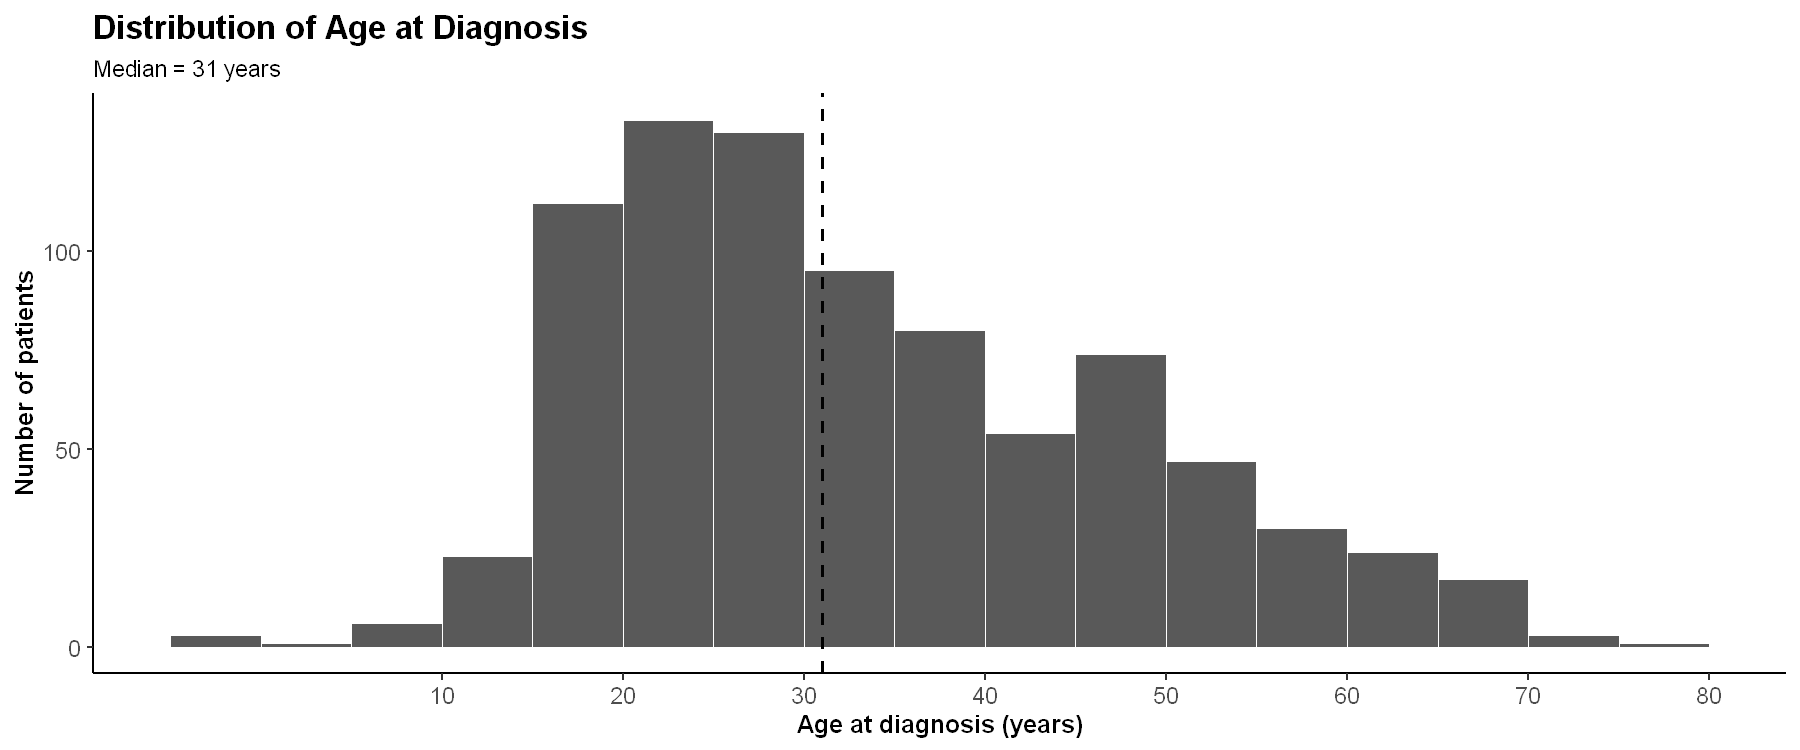

In [33]:
ggplot(df1, aes(x = age_diagnosis)) +
  geom_histogram( binwidth = 5,  boundary = 0,  color = "white",  linewidth = 0.4  ) +
  geom_vline(
    xintercept = median(df1$age_diagnosis, na.rm = TRUE),
    linetype = "dashed",
    linewidth = 0.8  ) +
  scale_x_continuous( breaks = seq(10, 80, by = 10)  ) +
  labs(
    title = "Distribution of Age at Diagnosis",
    subtitle = paste0( "Median = ",
      round(median(df1$age_diagnosis, na.rm = TRUE), 1),
      " years" ),
    x = "Age at diagnosis (years)",
    y = "Number of patients"  ) +
  theme_classic(base_size = 13) +
  theme(
    plot.title = element_text(face = "bold", size = 16),
    plot.subtitle = element_text(size = 11),
    axis.title = element_text(face = "bold", size = 12),
    axis.text = element_text(size = 11)
  )

Warning message:
"Removed 2 rows containing non-finite outside the scale range (`stat_bin()`)."


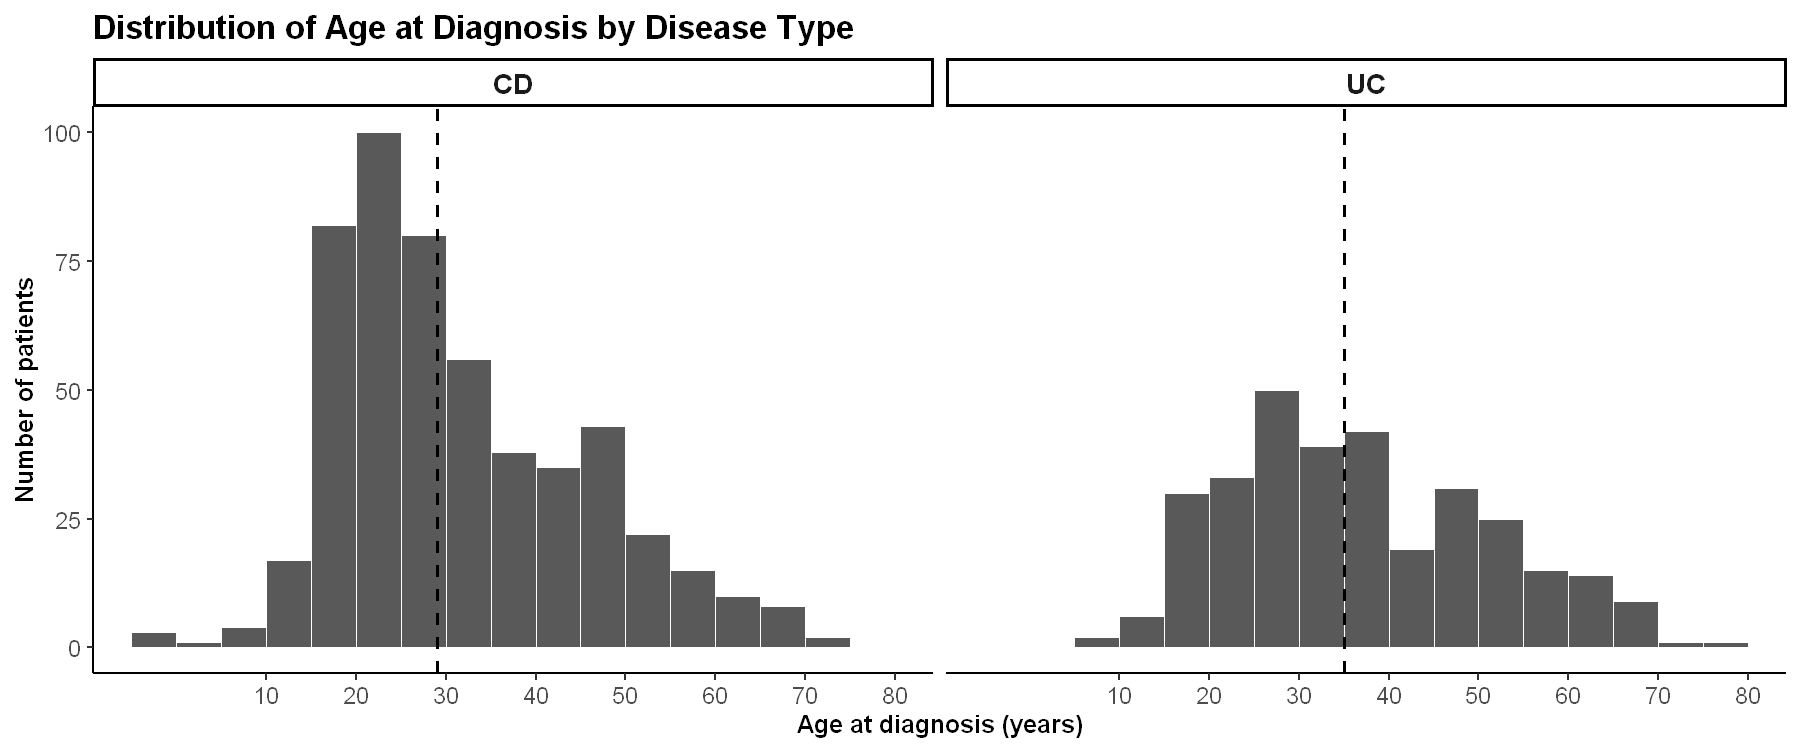

In [34]:
ggplot(df1, aes(x = age_diagnosis)) +
  geom_histogram(
    binwidth = 5,
    boundary = 0,
    color = "white",
    linewidth = 0.4
  ) +
  geom_vline(
    data = df1 %>%
      group_by(DiseaseEntity) %>%
      summarise(median_age = median(age_diagnosis, na.rm = TRUE)),
    aes(xintercept = median_age),
    linetype = "dashed",
    linewidth = 0.8
  ) +
  facet_wrap(~ DiseaseEntity) +
  scale_x_continuous(
    breaks = seq(10, 80, by = 10)
  ) +
  labs(
    title = "Distribution of Age at Diagnosis by Disease Type",
    x = "Age at diagnosis (years)",
    y = "Number of patients"
  ) +
  theme_classic(base_size = 13) +
  theme(
    plot.title = element_text(face = "bold", size = 16),
    axis.title = element_text(face = "bold", size = 12),
    axis.text = element_text(size = 11),
    strip.text = element_text(face = "bold", size = 13)
  )

From ibdc_date_1 until HM_TOTAL_38: all completions of IBD Control, Health Monitor and VAS fatigue. -- we are using HM_TOTAL values as the principal score



In [35]:
cat('baseline range:'); min(df$baseline, na.rm = TRUE) ; max(df$baseline, na.rm = TRUE)
head(df%>% select(baseline, PROM_comp_date_1))

baseline range:

[1] "2023-11-11 UTC"

[1] "2026-06-08 UTC"

baseline,PROM_comp_date_1
<dttm>,<date>
2024-04-27,2024-04-27
2023-11-15,2023-11-15
2024-07-03,2024-07-03
2023-11-29,2023-11-29
2024-11-23,2024-11-23
2025-11-09,2025-11-09


## I.3. Psychosocial Data Preparation

### I.3.1 fatigue scores

vas_fatigue columns are for fatigue along with a corresponding column for their baseline dates

In [36]:
vas_fatigueDF <- df_HM_TOTAL_%>% select("patientIdentifier", starts_with("vas_fatigue"), starts_with("vasft_date_") )
vas_fatigueDF$PROM_comp_date_1 <- df1$PROM_comp_date_1
#str(vas_fatigueDF)

In [37]:
# =====================================================================
# Select the VAS fatigue value for each patient if any of ibdc_date_1..7 falls within 12 months of PROM_comp_date_1
# =====================================================================


# Reshape the vas_fatigue_1..7 / ibdc_date_1..7 pairs to long format.
#    ONLY indices 1-7 are in scope.
vas_long <- vas_fatigueDF %>%
  select(patientIdentifier, PROM_comp_date_1,
         vas_fatigue_1:vas_fatigue_7,
         vasft_date_1:vasft_date_7) %>%
  pivot_longer(
    cols = c(vas_fatigue_1:vas_fatigue_7, vasft_date_1:vasft_date_7),
    names_to = c(".value", "visit"),
    names_pattern = "(vas_fatigue|vasft_date)_(\\d+)"
  ) %>%
  mutate(visit = as.integer(visit))          # visit index 1..7

#  Distance to baseline (days), drop rows with missing date OR vas value,
#    keep only visits within 12 months.
#    Choice: ±365 days (i.e. 365 days before AND after baseline).
vas_sel <- vas_long %>%
  mutate(
    vasft_date       = as.Date(vasft_date),
    PROM_comp_date_1 = as.Date(PROM_comp_date_1),
    day_diff = as.numeric(difftime(vasft_date, PROM_comp_date_1, units = "days"))
  ) %>%
  drop_na(vasft_date, vas_fatigue) %>%
  filter(abs(day_diff) <= 365)

# One row per patient: pick the visit closest to baseline (smallest
#    |day_diff|), breaking ties by the lowest visit index.
vas_final <- vas_sel %>%
  arrange(patientIdentifier, abs(day_diff), visit) %>%
  group_by(patientIdentifier) %>%
  slice(1) %>%
  ungroup() %>%
  select(patientIdentifier,
         vas_fatigue = vas_fatigue,
         visit_selected       = visit,
         ibdc_date_selected   = vasft_date,
         day_diff)

dim(vas_final)

[1] 835   5

In [38]:
#  Merge back: patients with no qualifying visit get NA
df1 <- df1 %>%
  left_join(vas_final %>% select(patientIdentifier, vas_fatigue), by = "patientIdentifier") 


In [39]:
table(df1$vas_fatigue, df1$flare_date_1)

    
     No Yes
  0  52  14
  1  81  20
  2  46  15
  3  44  22
  4  31  19
  5  73  31
  6  69  40
  7  79  35
  8  54  53
  9  26  16
  10  8   7

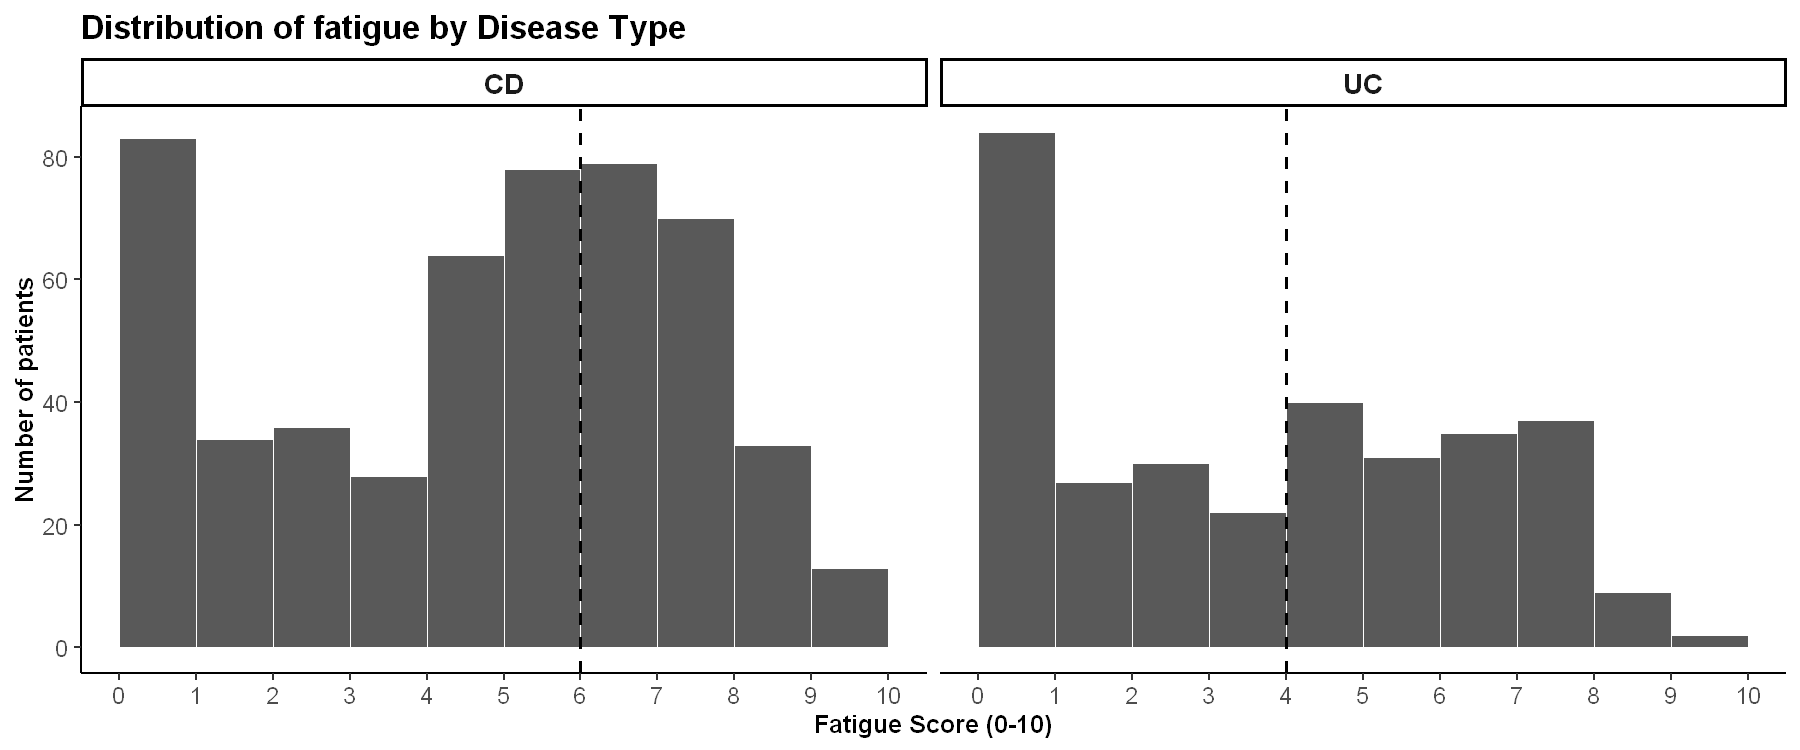

In [40]:
ggplot(df1, aes(x = vas_fatigue)) +
  geom_histogram( binwidth = 1, boundary = 0, color = "white", linewidth = 0.4  ) +
  geom_vline(
    data = df1 %>%
      group_by(DiseaseEntity) %>%
      summarise(median_age = median(vas_fatigue, na.rm = TRUE)),
    aes(xintercept = median_age),    linetype = "dashed",    linewidth = 0.8  ) +
  facet_wrap(~ DiseaseEntity) +
  scale_x_continuous(breaks = seq(0, 10, by = 1)  ) +
  labs(
    title = "Distribution of fatigue by Disease Type",
    x = "Fatigue Score (0-10)",
    y = "Number of patients"  ) +
  theme_classic(base_size = 13) +
  theme(
    plot.title = element_text(face = "bold", size = 16),
    axis.title = element_text(face = "bold", size = 12),
    axis.text = element_text(size = 11),
    strip.text = element_text(face = "bold", size = 13)  )

In [41]:
df1$vas_fatigue <- cut(
  df1$vas_fatigue,
  breaks = c(-1, 3, 6, 10),
  labels = c("Low (0-3)", "Moderate (4-6)", "High (7-10)")
)

table(df1$vas_fatigue, df1$flare_date_1)

                
                  No Yes
  Low (0-3)      223  71
  Moderate (4-6) 173  90
  High (7-10)    167 111

### I.3.2 stress scores

HM_TOTAL_1 till HM_TOTAL_38 are the values for stress collected. Please use the ones closer to the ones with active flare dates since we have the baseline date until 12 months after they are collected. (the total window is 12 months). Please check the ones for the corresponding date to this periods.

In [44]:
stressDF <- df_HM_TOTAL_%>% select("patientIdentifier", starts_with("HM_TOTAL"), starts_with("hm_date") )
stressDF$PROM_comp_date_1 <- df1$PROM_comp_date_1
#str(stressDF)

In [45]:
# =====================================================================
# Select the VAS stress value for each patient if any of hm_date_1..38 falls within 12 months of PROM_comp_date_1
# =====================================================================

# Reshape the HM_TOTAL_1..38 / hm_date_1..7 pairs to long format.
#    ONLY indices 1-7 are in scope.
vas_long <- stressDF %>%
  select(patientIdentifier, PROM_comp_date_1,
         HM_TOTAL_1:HM_TOTAL_38,
         hm_date_1:hm_date_38) %>%
  pivot_longer(
    cols = c(HM_TOTAL_1:HM_TOTAL_38, hm_date_1:hm_date_38),
    names_to = c(".value", "visit"),
    names_pattern = "(HM_TOTAL|hm_date)_(\\d+)"
  ) %>%
  mutate(visit = as.integer(visit))          # visit index 1..7

#  Distance to baseline (days), drop rows with missing date OR vas value,
#    keep only visits within 12 months.
#    Choice: ±365 days (i.e. 365 days before AND after baseline).
vas_sel <- vas_long %>%
  mutate(
    hm_date       = as.Date(hm_date),
    PROM_comp_date_1 = as.Date(PROM_comp_date_1),
    day_diff = as.numeric(difftime(hm_date, PROM_comp_date_1, units = "days"))
  ) %>%
  drop_na(hm_date, HM_TOTAL) %>%
  filter(abs(day_diff) <= 365)

# One row per patient: pick the visit closest to baseline (smallest
#    |day_diff|), breaking ties by the lowest visit index.
vas_final <- vas_sel %>%
  arrange(patientIdentifier, abs(day_diff), visit) %>%
  group_by(patientIdentifier) %>%
  slice(1) %>%
  ungroup() %>%
  select(patientIdentifier,
         vas_stress = HM_TOTAL,
         visit_selected       = visit,
         date_selected   = hm_date,
         day_diff)

dim(vas_final)

[1] 835   5

In [46]:
#  Merge back: patients with no qualifying visit get NA
df1 <- df1 %>%
  left_join(vas_final %>% select(patientIdentifier, vas_stress), by = "patientIdentifier") 
df1$vas_stress <- factor(df1$vas_stress, levels = c(1, 2,3,4), labels =  c("low IBD-related stress", "medium IBD-related stress","medium IBD-related stress", "high IBD-related stress"))

In [47]:
table(df1$vas_stress)


   low IBD-related stress medium IBD-related stress   high IBD-related stress 
                      274                       254                       307 


### I.3.2  anxiety and depression scores

Ibdcontrol columns is the value in the data for both anxiety and depression together (the dates columns are around their baseline)


In [48]:
IbdcontrolDF <- df_HM_TOTAL_%>% select("patientIdentifier", starts_with("anxious_or_depressed"), starts_with("ibdc_date_") )
IbdcontrolDF$PROM_comp_date_1 <- df1$PROM_comp_date_1
# str(IbdcontrolDF)

In [49]:
# =====================================================================
# Select the VAS stress value for each patient if any of hm_date_1..38 falls within 12 months of PROM_comp_date_1
# =====================================================================

# Reshape the HM_TOTAL_1..38 / hm_date_1..7 pairs to long format.
#    ONLY indices 1-7 are in scope.
vas_long <- IbdcontrolDF %>%
  select(patientIdentifier, PROM_comp_date_1,
         anxious_or_depressed_3e_1:anxious_or_depressed_3e_10,
         ibdc_date_1:ibdc_date_10) %>%
  pivot_longer(
    cols = c(anxious_or_depressed_3e_1:anxious_or_depressed_3e_10, ibdc_date_1:ibdc_date_10),
    names_to = c(".value", "visit"),
    names_pattern = "(anxious_or_depressed_3e|ibdc_date)_(\\d+)"
  ) %>%
  mutate(visit = as.integer(visit))          # visit index 1..7

#  Distance to baseline (days), drop rows with missing date OR vas value,
#    keep only visits within 12 months.
#    Choice: ±365 days (i.e. 365 days before AND after baseline).
vas_sel <- vas_long %>%
  mutate(
    ibdc_date       = as.Date(ibdc_date),
    PROM_comp_date_1 = as.Date(PROM_comp_date_1),
    day_diff = as.numeric(difftime(ibdc_date, PROM_comp_date_1, units = "days"))
  ) %>%
  drop_na(ibdc_date, anxious_or_depressed_3e) %>%
  filter(abs(day_diff) <= 365)

# One row per patient: pick the visit closest to baseline (smallest
#    |day_diff|), breaking ties by the lowest visit index.
vas_final <- vas_sel %>%
  arrange(patientIdentifier, abs(day_diff), visit) %>%
  group_by(patientIdentifier) %>%
  slice(1) %>%
  ungroup() %>%
  select(patientIdentifier,
         vas_anxious_or_depressed = anxious_or_depressed_3e,
         visit_selected       = visit,
         date_selected   = ibdc_date,
         day_diff)

dim(vas_final)

[1] 835   5

In [50]:
#  Merge back: patients with no qualifying visit get NA
df1 <- df1 %>%
  left_join(vas_final %>% select(patientIdentifier, vas_anxious_or_depressed), by = "patientIdentifier") 

df1$vas_anxious_or_depressed <- factor(df1$vas_anxious_or_depressed, levels = c(0,1, 2), labels =  c("Yes", "Not sure", "No"))

In [51]:
table(df1$vas_anxious_or_depressed)


     Yes Not sure       No 
      82       70      683 

In [52]:
table(df1$vas_anxious_or_depressed)



     Yes Not sure       No 
      82       70      683 



## I.4 Prepare Medicament data

In [53]:
dataMed <- read_excel("./Other medication v6.xlsx")%>% 
  mutate(
    patientIdentifier = as.character(patientIdentifier),
    start_date        = as.Date(start_date),
    stop_date         = as.Date(stop_date),
    effectiveDate     = as.Date(effectiveDate)  )
cat('RAW ROWS:', nrow(dataMed))

RAW ROWS: 10473

In [54]:
str(dataMed)

tibble [10,473 × 13] (S3: tbl_df/tbl/data.frame)
 $ patientIdentifier: chr [1:10473] "1001822" "1001822" "1003190" "1003190" ...
 $ effectiveDate    : Date[1:10473], format: "2022-03-08" "2022-10-25" ...
 $ medicine_id      : num [1:10473] 32 14 32 29 28 28 29 32 7 30 ...
 $ route_id         : num [1:10473] 8 11 8 8 8 8 8 8 8 9 ...
 $ frequency_id     : num [1:10473] 1 17 1 3 1 1 1 1 12 1 ...
 $ dose             : chr [1:10473] "10" "40" "20" "3" ...
 $ unit_id          : num [1:10473] 2 2 2 2 3 3 2 2 2 2 ...
 $ start_date       : Date[1:10473], format: "2022-03-08" "2022-06-08" ...
 $ brand            : chr [1:10473] NA "Amgevita" NA "Budenofalk" ...
 $ othermedicine    : chr [1:10473] NA NA NA NA ...
 $ stop_date        : Date[1:10473], format: "2026-06-30" "2026-06-30" ...
 $ stopreason_id    : num [1:10473] NA NA NA NA NA NA NA NA NA 6 ...
 $ stop_text        : chr [1:10473] NA NA NA NA ...


In [55]:
cat(" Before filtering:")

cat("\n dataMed:", nrow(dataMed), " rows and " , ncol(dataMed), "columns.")

cat("\n dataMed contained: ", length(unique(dataMed$patientIdentifier)), "  unique patients.")

cat("\n df1 contained: ", length(unique(df1$patientIdentifier)), "  unique patients.")


 Before filtering:
 dataMed: 10473  rows and  13 columns.
 dataMed contained:  3762   unique patients.
 df1 contained:  835   unique patients.

`dataMed` initially included medication records for many patients who were **not part of the 835-patient df1 cohort**.

In [56]:

dataMed_df1 <- dataMed %>%
  filter(patientIdentifier %in% df1$patientIdentifier)


In [57]:
cat(" After keeping only patients from `df1`:")

cat("\n dataMed_df1:", nrow(dataMed_df1), " rows and " , ncol(dataMed_df1), "columns.")

cat("\n dataMed_df1: ", length(unique(dataMed_df1$patientIdentifier)), "  unique patients.")

cat("\n df1: ", length(unique(df1$patientIdentifier)), "  unique patients.")


 After keeping only patients from `df1`:
 dataMed_df1: 2575  rows and  13 columns.
 dataMed_df1:  777   unique patients.
 df1:  835   unique patients.

df1` contains **835 patients**, only **777 (93.1%)** of them have at least one medication record in `dataMed`.

The remaining:

**835 − 777 = 58 patients (6.9%)** have **no corresponding medication record** in `dataMed`.

In [58]:
missing_med <- setdiff(
  df1$patientIdentifier,
  dataMed_df1$patientIdentifier
)

length(missing_med)
missing_med

[1] 58

[1] "1276562"  "1373343"  "1493878"  "1532026"  "1672069"  "1809361" 
 [7] "18354715" "2017729"  "2061053"  "2142733"  "2146076"  "2510352" 
[13] "2730052"  "2940647"  "3177864"  "3226520"  "3231802"  "3365993" 
[19] "3409652"  "3479219"  "3753165"  "42192781" "4295969"  "4315419" 
[25] "435367"   "4526656"  "4559593"  "4560399"  "4581125"  "4723963" 
[31] "4831968"  "5166363"  "5467804"  "552166"   "6730091"  "7773066" 
[37] "778373"   "7929450"  "8170634"  "8597439"  "8761428"  "98462"   
[43] "1639597"  "1944116"  "20553735" "21107680" "2213421"  "23158003"
[49] "3787589"  "4108154"  "4580328"  "4747066"  "5362187"  "69797137"
[55] "8267334"  "8432884"  "8432975"  "85641"

In [59]:
df1 <- df1 %>%
  filter(patientIdentifier %in% dataMed_df1$patientIdentifier)

In [60]:


# ---- 1. Medicine lookup (codes EXACTLY as in the codebook - other added for  98,73,110,49) ----
med_lookup <- tibble(
  medicine_id = c(0, 4, 7, 10, 12, 14, 22, 28, 29, 30, 31, 32, 33, 34, 35, 38,
                  41, 42, 44, 45, 47, 54, 58, 60, 70, 77, 80, 88, 99,
                 98,73,110,49),
  medicine_name = c("Overig", "Ciclosporine", "Methotrexaat", "Azathioprine",
                    "Infliximab", "Adalimumab", "Golimumab", "Mesalazine_oraal",
                    "Budesonide", "Beclomethason", "Mercaptopurine", "Tioguanine",
                    "Vedolizumab", "Tacrolimus", "Mesalazine_klysma", "Sulfasalazine",
                    "Tofacitinib", "Ustekinumab", "Allopurinol", "Antibiotica",
                    "Dexamethason", "Mirikizumab", "Triamcinolonacetonide", "Olsalazine",
                    "Ozanimod", "Filgotinib", "Risankizumab", "Upadicitinib",
                    "Systemic_corticosteroids", "other", "other","other", "other"),
  drug_class = c("other", "immunomodulator", "immunomodulator", "immunomodulator",
                 "advanced_therapy", "advanced_therapy", "advanced_therapy", "5asa",
                 "corticosteroid_local", "corticosteroid_local", "immunomodulator",
                 "immunomodulator", "advanced_therapy", "immunomodulator",
                 "5asa", "5asa", "advanced_therapy", "advanced_therapy",
                 "other", "other", "corticosteroid_systemic", "advanced_therapy",
                 "corticosteroid_local", "5asa", "advanced_therapy", "advanced_therapy",
                 "advanced_therapy", "advanced_therapy", "corticosteroid_systemic", 
                 "other", "other","other", "other")
)

# Stop sanity check: any medicine_id in our data that isn't in the codebook?
stopifnot(all(unique(dataMed_df1$medicine_id) %in% med_lookup$medicine_id))
cat("All medicine_id codes are in the codebook lookup. OK\n")


All medicine_id codes are in the codebook lookup. OK


In [61]:
# ---- 3COLLAPSE per patient x medicine BEFORE any join (prevents fan-out) ----
med_collapsed <- dataMed_df1 %>%
  group_by(patientIdentifier, medicine_id) %>%
  summarise(
    start_earliest = min(start_date, na.rm = TRUE),
    stop_latest    = max(stop_date, na.rm = TRUE),   # NA => ongoing
    n_courses      = n(),                                  # rows collapsed per pair
    .groups = "drop"
  ) %>%
  left_join(med_lookup, by = "medicine_id")

In [62]:
# ---- 5. Per-patient summary: any exposure per drug / per class ----
patient_meds <- med_collapsed %>%
  group_by(patientIdentifier) %>%
  summarise(
    n_drugs_active          = n_distinct(medicine_name),
    any_advanced_therapy    = any(drug_class == "advanced_therapy"),
    any_immunomodulator     = any(drug_class == "immunomodulator"),
    any_5asa                = any(drug_class == "5asa"),
    any_corticosteroid      = any(drug_class %in% c("corticosteroid_systemic",
                                                    "corticosteroid_local")),
    any_corticosteroid_syst = any(drug_class == "corticosteroid_systemic"),
    .groups = "drop"
  ) %>%
  mutate(across(c(any_advanced_therapy, any_immunomodulator, any_5asa,
                  any_corticosteroid, any_corticosteroid_syst), as.integer))

In [63]:
# One flag column per medicine (wide), using the exact medicine_id codes as names
active_wide <- med_collapsed %>%
  distinct(patientIdentifier, medicine_name) %>%
  mutate(value = 1L) %>%
  pivot_wider(id_cols = patientIdentifier,
              names_from = medicine_name,
              names_prefix = "drug_",
              values_from = value,
              values_fill = list(value = 0L))

In [64]:
# ---- 6. LEFT JOIN onto df1 (stays at 835 rows) ----
df1 <- df1 %>%
  left_join(patient_meds, by = "patientIdentifier") %>%
  left_join(active_wide,  by = "patientIdentifier") %>%
  mutate(across(c(n_drugs_active, any_advanced_therapy, any_immunomodulator,
                  any_5asa, any_corticosteroid, any_corticosteroid_syst),
                ~ replace_na(.x, 0L)))

In [65]:
df1$birthdate <- NULL
df1$PROM_comp_date_1  <- NULL 
df1$year_diagnosis  <- NULL 

df1 <- df1 %>%
  select(-flare_date_1, everything(), flare_date_1)
 

**Output columns added to df1**: `n_drugs_active`, the class flags (`any_advanced_therapy`, `any_immunomodulator`, `any_5asa`, `any_corticosteroid`, `any_corticosteroid_syst`), plus one binary flag per medicine (infliximab,  ustekinumab, etc.) — patients with no record get 0/FALSE via the values_fill and replace_na, never NA.

In [66]:
df1 <- df1 %>%
  mutate(
    across(
      c(ends_with("_ever"), any_surgery, PerianalDisease , starts_with("drug_"),
       any_advanced_therapy,any_immunomodulator, 
       any_5asa, any_corticosteroid, any_corticosteroid_syst, any_5asa, any_corticosteroid, any_corticosteroid_syst),
      ~ factor(.x, levels = c(0, 1), labels = c("No", "Yes"))
    )
  )

In [67]:
## 1. Set NA = 0 for surgery-related features

surgery_vars <- c(
  "surg_colon_resection_age",
  "surg_subtotal_colectomy_age",
  "surg_fistula_abcess_age",
  "surg_ileo_anal_pouch_age",
  "surg_small_bowel_resection_age",
  "surg_ileocaecal_resection_age",
  "surg_colostoma_age",
  "surg_proctectomy_age",
  "surg_small_bowel_stoma_age",
  "surg_stoma_reversal_age",
  "surg_proctocolectomy_age",
  "surg_stenoplasty_age",
  "surg_B2_stomach_age",
  "age_first_surgery",
  "age_last_surgery",
  "mean_age_surgery",
  "mean_days_between_surgeries",
  "days_first_to_last_surgery"
)

df1[surgery_vars] <- lapply(
  df1[surgery_vars],
  function(x) {
    x[is.na(x)] <- 0
    x
  }
)




#  II. Statistics

### II.1 DV Statistics

The output table indicates that among the participants, 510 (65.6%) experienced no flares, while 267 (**34.4%**) **reported experiencing flares**.


In [68]:
# Compute frequency and percentage of GroupNewReversed
group_summary <- df1 %>%
  group_by(flare_date_1) %>%
  summarise(Frequency = n(),
            Percentage = (n() / nrow(df1)) * 100) %>%
  ungroup()

# Format the table as a Markdown table
markdown_table <- group_summary %>%
  mutate(Percentage = round(Percentage, 1)) %>%  # Round percentage to one decimal place
  rename(
         `Frequency (N)` = Frequency,
         `Percentage (%)` = Percentage) %>%
  kable(format = "markdown", align = "c")

# Display the Markdown table
markdown_table



| flare_date_1 | Frequency (N) | Percentage (%) |
|:------------:|:-------------:|:--------------:|
|      No      |      510      |      65.6      |
|     Yes      |      267      |      34.4      |

In [69]:
library(dplyr)
library(tidyr)
library(knitr)
library(openxlsx)

# =========================================================
# 1. HELPER: p-value for a categorical variable vs Flares
#    (chi-square, falls back to Fisher's exact if any
#    expected cell count < 5)
# =========================================================
calc_cat_pvalue <- function(x, group) {
  tab <- table(x, group)
  if (any(dim(tab) < 2)) return(NA)  # not enough categories to test

  expected <- suppressWarnings(chisq.test(tab)$expected)
  if (any(expected < 5)) {
    p <- fisher.test(tab, simulate.p.value = TRUE, B = 10000)$p.value
  } else {
    p <- chisq.test(tab)$p.value
  }
  round(p, 5)
}

# =========================================================
# 2. HELPER: p-value for a numeric variable vs Flares
#    (two-sample t-test; works for any two group labels,
#    not just "Yes"/"No")
# =========================================================
calc_num_pvalue <- function(x, group) {
  groups <- na.omit(unique(group))
  if (length(groups) != 2) return(NA)  # t-test needs exactly 2 groups

  g1 <- x[group == groups[1]]; g1 <- g1[!is.na(g1)]
  g2 <- x[group == groups[2]]; g2 <- g2[!is.na(g2)]

  if (length(g1) >= 2 && length(g2) >= 2) {
    round(t.test(g1, g2)$p.value, 5)
  } else {
    NA
  }
}

# =========================================================
# 3. MASTER FUNCTION: run categorical + continuous analysis
#    on a slice of columns, against a grouping variable
#    Returns a list(categorical = ..., continuous = ...)
# =========================================================
analyze_flare_section <- function(df, col_range, flare_var = "flare_date_1") {

  section_data <- df[col_range]
  flare <- df[[flare_var]]

  # ---------- Categorical variables ----------
  qual_vars <- section_data %>% select(where(is.factor))
  qual_result <- NULL

  if (ncol(qual_vars) > 0) {
    qual_data <- qual_vars %>% mutate(across(everything(), as.character))
    qual_data$Flares <- flare

    cross_freq <- qual_data %>%
      pivot_longer(-Flares, names_to = "Factor", values_to = "Value") %>%
      group_by(Factor, Flares, Value) %>%
      summarise(Freq = n(), .groups = "drop") %>%
      group_by(Flares, Factor) %>%
      mutate(Pct = round(Freq / sum(Freq) * 100, 2)) %>%
      ungroup() %>%
      rename(Category = Value)

    var_names <- setdiff(names(qual_data), "Flares")
    p_vals <- sapply(var_names, function(v) calc_cat_pvalue(qual_data[[v]], qual_data$Flares))
    p_df <- data.frame(Factor = var_names, p_value = p_vals, row.names = NULL) %>%
      arrange(p_value)

    qual_result <- cross_freq %>%
      left_join(p_df, by = "Factor") %>%
      mutate(Factor = factor(Factor, levels = p_df$Factor)) %>%
      arrange(Factor, Flares, Category)
  }

  # ---------- Continuous variables ----------
  num_vars <- section_data %>% select(where(is.numeric))
  quant_result <- NULL

  if (ncol(num_vars) > 0) {
    num_data <- num_vars
    num_data$Flares <- factor(flare)

    summary_stats <- num_data %>%
      group_by(Flares) %>%
      summarise(across(where(is.numeric),
                        ~ paste0(round(mean(., na.rm = TRUE), 2), " (",
                                 round(sd(., na.rm = TRUE), 2), ")")),
                .groups = "drop")

    var_names <- names(num_data)[names(num_data) != "Flares"]
    p_vals <- sapply(var_names, function(v) calc_num_pvalue(num_data[[v]], num_data$Flares))
    p_df <- data.frame(Variable = var_names, p_value = p_vals, row.names = NULL)

    quant_result <- summary_stats %>%
      pivot_longer(-Flares, names_to = "Variable", values_to = "Value") %>%
      pivot_wider(names_from = Flares, values_from = Value) %>%
      left_join(p_df, by = "Variable") %>%
      arrange(p_value)
  }

  list(categorical = qual_result, continuous = quant_result)
}


Warning message:
"package 'openxlsx' was built under R version 4.5.2"


## II.1 Baseline Statistics

Baseline: columns 2 to 50

In [70]:
baseline     <- analyze_flare_section(df1, 2:50,  "flare_date_1")  # II.1 Baseline

kable(baseline$categorical, format = "markdown", align = "c")
kable(baseline$continuous, format = "markdown", align = "c")



|             Factor              | Flares |    Category    | Freq |  Pct   | p_value |
|:-------------------------------:|:------:|:--------------:|:----:|:------:|:-------:|
|            any_stoma            |   No   |       No       | 488  | 95.69  | 0.00815 |
|            any_stoma            |   No   |      Yes       |  22  |  4.31  | 0.00815 |
|            any_stoma            |  Yes   |       No       | 242  | 90.64  | 0.00815 |
|            any_stoma            |  Yes   |      Yes       |  25  |  9.36  | 0.00815 |
|          current_stoma          |   No   |       No       | 490  | 96.08  | 0.01072 |
|          current_stoma          |   No   |      Yes       |  20  |  3.92  | 0.01072 |
|          current_stoma          |  Yes   |       No       | 244  | 91.39  | 0.01072 |
|          current_stoma          |  Yes   |      Yes       |  23  |  8.61  | 0.01072 |
|   surg_small_bowel_stoma_ever   |   No   |       No       | 494  | 96.86  | 0.03172 |
|   surg_small_bowel_stoma_eve



|            Variable            |        No        |       Yes        | p_value |
|:------------------------------:|:----------------:|:----------------:|:-------:|
|   surg_small_bowel_stoma_age   |   1.02 (6.15)    |   2.57 (10.06)   | 0.02198 |
|      surg_proctectomy_age      |   0.35 (3.64)    |      0 (0)       | 0.03120 |
|    surg_ileo_anal_pouch_age    |   0.23 (2.58)    |      0 (0)       | 0.04593 |
|        mean_age_surgery        |  10.45 (18.09)   |  13.29 (19.77)   | 0.05027 |
|        age_last_surgery        |  10.93 (18.87)   |  13.88 (20.57)   | 0.05107 |
|       age_first_surgery        |  10.01 (17.57)   |  12.64 (19.15)   | 0.06243 |
|    surg_stoma_reversal_age     |    0.78 (5.4)    |   1.82 (8.43)    | 0.06977 |
|          n_surgeries           |    0.45 (0.9)    |   0.57 (0.97)    | 0.09941 |
| surg_ileocaecal_resection_age  |    5.2 (13.4)    |   7.02 (15.69)   | 0.10782 |
|              BMI               |   25.74 (4.69)   |   26.38 (5.76)   | 0.11655 |
| 

## II.2 psychosocial Statistics

In [71]:
psychosocial <- analyze_flare_section(df1, 51:53, "flare_date_1")  # II.2 Psychosocial

kable(psychosocial$categorical, format = "markdown", align = "c")



|          Factor          | Flares |         Category          | Freq |  Pct  | p_value |
|:------------------------:|:------:|:-------------------------:|:----:|:-----:|:-------:|
|        vas_stress        |   No   |  high IBD-related stress  | 152  | 29.80 | 0.00000 |
|        vas_stress        |   No   |  low IBD-related stress   | 196  | 38.43 | 0.00000 |
|        vas_stress        |   No   | medium IBD-related stress | 162  | 31.76 | 0.00000 |
|        vas_stress        |  Yes   |  high IBD-related stress  | 140  | 52.43 | 0.00000 |
|        vas_stress        |  Yes   |  low IBD-related stress   |  51  | 19.10 | 0.00000 |
|        vas_stress        |  Yes   | medium IBD-related stress |  76  | 28.46 | 0.00000 |
| vas_anxious_or_depressed |   No   |            No             | 436  | 85.49 | 0.00009 |
| vas_anxious_or_depressed |   No   |         Not sure          |  38  | 7.45  | 0.00009 |
| vas_anxious_or_depressed |   No   |            Yes            |  36  | 7.06  | 0.00009

## II.3 Medicament Statistics

In [72]:
medicament   <- analyze_flare_section(df1, 54:85, "flare_date_1")  # II.4 Medicament

kable(medicament$categorical, format = "markdown", align = "c")
kable(medicament$continuous, format = "markdown", align = "c")



|            Factor             | Flares | Category | Freq |  Pct   | p_value |
|:-----------------------------:|:------:|:--------:|:----:|:------:|:-------:|
|     any_advanced_therapy      |   No   |    No    | 206  | 40.39  | 0.00000 |
|     any_advanced_therapy      |   No   |   Yes    | 304  | 59.61  | 0.00000 |
|     any_advanced_therapy      |  Yes   |    No    |  58  | 21.72  | 0.00000 |
|     any_advanced_therapy      |  Yes   |   Yes    | 209  | 78.28  | 0.00000 |
|      any_corticosteroid       |   No   |    No    | 387  | 75.88  | 0.00000 |
|      any_corticosteroid       |   No   |   Yes    | 123  | 24.12  | 0.00000 |
|      any_corticosteroid       |  Yes   |    No    | 142  | 53.18  | 0.00000 |
|      any_corticosteroid       |  Yes   |   Yes    | 125  | 46.82  | 0.00000 |
|    any_corticosteroid_syst    |   No   |    No    | 467  | 91.57  | 0.00000 |
|    any_corticosteroid_syst    |   No   |   Yes    |  43  |  8.43  | 0.00000 |
|    any_corticosteroid_syst    |  Yes



|    Variable    |     No      |     Yes     | p_value |
|:--------------:|:-----------:|:-----------:|:-------:|
| n_drugs_active | 1.85 (1.16) | 2.85 (1.77) |    0    |

In [77]:
library(dplyr)
library(tidyr)
library(knitr)
library(openxlsx)

# =========================================================
# 1. FORMATTING HELPERS
# =========================================================

fmt_n_pct <- function(n, pct) {
  n   <- ifelse(is.na(n), 0, n)
  pct <- ifelse(is.na(pct), 0, pct)
  sprintf("%d (%.1f%%)", n, pct)
}

fmt_mean_sd <- function(m, s) {
  if (is.na(m) || is.na(s)) return("")
  sprintf("%.2f (%.2f)", m, s)
}

format_p <- function(p) {
  if (is.na(p)) return("")
  if (p < 0.001) return("<0.001")
  sprintf("%.3f", p)
}


# =========================================================
# 3. p-VALUE HELPERS
# =========================================================

calc_cat_pvalue <- function(x, group) {
  tab <- table(x, group)
  if (any(dim(tab) < 2)) return(NA)

  expected <- suppressWarnings(chisq.test(tab)$expected)
  if (any(expected < 5)) {
    fisher.test(tab, simulate.p.value = TRUE, B = 10000)$p.value
  } else {
    chisq.test(tab)$p.value
  }
}

calc_num_pvalue <- function(x, group, g1lab, g2lab) {
  g1 <- x[group == g1lab]; g1 <- g1[!is.na(g1)]
  g2 <- x[group == g2lab]; g2 <- g2[!is.na(g2)]
  if (length(g1) >= 2 && length(g2) >= 2) {
    t.test(g1, g2)$p.value
  } else {
    NA
  }
}

# =========================================================
# 4. ROW BUILDERS
# =========================================================
# Internally every block uses the SAME fixed column names
# (Variable, `All patients [n (%) / mean (SD)]`, Grp1, Grp2,
#  `p-value`). Grp1/Grp2 are renamed to the
# user's group_labels, by exact name match, once in
# build_table1() -- so this can't silently corrupt a column.

ALL_COL <- "All patients [n (%) / mean (SD)]"
DASH    <- ""  # em dash, used for cells that don't apply

# One block of rows for a categorical variable: a header row
# (variable name, dashes in the value columns,+
# p-value) followed by one row per category with n (col %)
# for All patients / No Flare / Flare.
build_categorical_block <- function(varname, x, group, group_labels) {

  tab <- table(x, group)
  if (any(dim(tab) < 2)) return(NULL)

  p_val <- calc_cat_pvalue(x, group)

  n_all <- table(x)
  n_g1  <- table(x[group == group_labels[1]])
  n_g2  <- table(x[group == group_labels[2]])

  pct_all <- round(n_all / length(x) * 100, 1)
  pct_g1  <- round(n_g1 / sum(group == group_labels[1]) * 100, 1)
  pct_g2  <- round(n_g2 / sum(group == group_labels[2]) * 100, 1)

  levels_x <- sort(unique(x))

  header_row <- data.frame(
    Variable      = varname,
    AllCol        = DASH,
    Grp1          = DASH,
    Grp2          = DASH,
    `p-value`     = format_p(p_val),
    check.names = FALSE, stringsAsFactors = FALSE
  )
  names(header_row)[2] <- ALL_COL

  body_rows <- bind_rows(lapply(levels_x, function(lv) {
    row <- data.frame(
      Variable      = paste0("   ", lv),
      AllCol        = fmt_n_pct(n_all[lv], pct_all[lv]),
      Grp1          = fmt_n_pct(n_g1[lv],  pct_g1[lv]),
      Grp2          = fmt_n_pct(n_g2[lv],  pct_g2[lv]),
      `p-value`     = DASH,
      check.names = FALSE, stringsAsFactors = FALSE
    )
    names(row)[2] <- ALL_COL
    row
  }))

  bind_rows(header_row, body_rows)
}

# One row for a continuous variable: mean (SD) per group,
# Cohen's d, and p-value.
build_continuous_block <- function(varname, x, group, group_labels) {
  keep  <- !is.na(x)
  x     <- x[keep]
  group <- group[keep]

  g1 <- x[group == group_labels[1]]
  g2 <- x[group == group_labels[2]]

  if (length(g1) < 2 || length(g2) < 2) return(NULL)

  p_val <- calc_num_pvalue(x, group, group_labels[1], group_labels[2])

  row <- data.frame(
    Variable      = varname,
    AllCol        = fmt_mean_sd(mean(x), sd(x)),
    Grp1          = fmt_mean_sd(mean(g1), sd(g1)),
    Grp2          = fmt_mean_sd(mean(g2), sd(g2)),
    `p-value`     = format_p(p_val),
    check.names = FALSE, stringsAsFactors = FALSE
  )
  names(row)[2] <- ALL_COL
  row
}

# =========================================================
# 5. MASTER FUNCTION
#    Builds the full Table 1 across a slice of columns.
#
#    df           : source data frame
#    col_range    : columns (names or indices) to summarize
#    flare_var    : column holding the grouping variable
#                   (must have exactly 2 levels)
#    group_labels : c(label_for_level1, label_for_level2) —
#                   check that this matches the actual coding
#                   of flare_var (e.g. "No"/"Yes", 0/1) before
#                   trusting the No Flare / Flare columns.
# =========================================================
build_table <- function(df, col_range, flare_var = "flare_date_1",
                          group_labels = c("No Flare", "Flare")) {

  section_data <- df[col_range]
  raw_group    <- df[[flare_var]]
  raw_levels   <- levels(factor(raw_group))

  if (length(raw_levels) != 2) {
    stop("flare_var must have exactly two levels to build this table")
  }

  group <- factor(raw_group, labels = group_labels)

  blocks <- lapply(names(section_data), function(v) {
    x <- section_data[[v]]
    if (is.factor(x) || is.character(x)) {
      build_categorical_block(v, x, group, group_labels)
    } else if (is.numeric(x)) {
      build_continuous_block(v, x, group, group_labels)
    } else {
      NULL
    }
  })

  out <- bind_rows(blocks)

  # Grp1 / Grp2 are the only placeholder names left to fix -- rename
  # them by POSITION to the user-supplied group_labels. Variable,
  # the "All patients" column, and p-value are already
  # named correctly by the row builders, so this can't silently
  # corrupt a column the way the previous version did.
  names(out)[names(out) == "Grp1"] <- group_labels[1]
  names(out)[names(out) == "Grp2"] <- group_labels[2]

  out
}


In [78]:

OverALLtable <- build_table(df1, col_range = 5:85, flare_var = "flare_date_1",
                         group_labels = c("No Flare", "Flare"))

write.csv(OverALLtable, "IBD_Flare_Statistics.csv", row.names = FALSE)

## III. GLASSO Models
### III.1. Feature Extraction

In [79]:
# Standardize numerical predictors
# Set dataset parameters
#=========================

## 1. Standardize numerical predictors
numeric_vars <- sapply(df1[c(-1)], is.numeric)

df1[c(-1)][numeric_vars] <- lapply(
  df1[c(-1)][numeric_vars],
  function(x) as.numeric(scale(x))
)
df1$flare_date_1  = factor(df1$flare_date_1)

In [80]:
# Set dataset parameters
#=========================
## 1. Create data matrix for independent variables 
### one-hotmatrix


library(fastDummies)


# Predictors
x <- df1 %>% select( -flare_date_1, -patientIdentifier)

# Identify categorical variables
categorical_vars <- names(x)[sapply(x, is.factor)]

# Create dummy variables
x_dummy <- dummy_cols(
  x,
  select_columns = categorical_vars,
  remove_first_dummy = TRUE,
  remove_selected_columns = TRUE
)

# Convert to matrix
model_matrix <- x_dummy%>%
    select(-ends_with("NA"))%>%
            select(
        Gender_Male  ,
        DiseaseEntity_UC ,
        age_diagnosis  ,
         montreal_extent_uc_E2,
         montreal_extent_uc_E3 ,              
         montreal_location_cd_L4,             
         montreal_location_cd_L2 ,            
         montreal_location_cd_L3  ,           
         montreal_activity_cd_B2   ,          
         montreal_activity_cd_B3    ,         
        PerianalDisease_Yes          ,       
        BMI   ,                      
         Family_IBD_final_TRUE     ,          
         Family_Crohn_TRUE          ,         
         Family_Colitis_TRUE       ,
                    
        surg_colon_resection_age ,           
        surg_subtotal_colectomy_age,         
        surg_fistula_abcess_age  ,           
        surg_ileo_anal_pouch_age ,           
        surg_small_bowel_resection_age ,     
        surg_ileocaecal_resection_age ,      
        surg_colostoma_age   ,               
        surg_proctectomy_age  ,              
        surg_small_bowel_stoma_age ,         
        surg_stoma_reversal_age  ,           
        surg_proctocolectomy_age  ,          
        surg_stenoplasty_age   ,             
        surg_B2_stomach_age,                 
        n_surgeries ,                        
        age_first_surgery ,                  
        age_last_surgery  ,                  
        mean_age_surgery  ,                  
        mean_days_between_surgeries  ,       
        days_first_to_last_surgery  ,                        
                         
        any_ibd_surgery_Yes  ,               
        any_ibd_resection_Yes   ,            
        any_stoma_Yes  ,                     
         current_stoma_Yes   ,                
         surg_colon_resection_ever_Yes  ,     
         surg_subtotal_colectomy_ever_Yes   , 
         surg_fistula_abcess_ever_Yes ,       
        surg_ileo_anal_pouch_ever_Yes  ,     
        surg_small_bowel_resection_ever_Yes ,
         surg_ileocaecal_resection_ever_Yes , 
        surg_colostoma_ever_Yes    ,         
         surg_proctectomy_ever_Yes  ,         
         surg_small_bowel_stoma_ever_Yes  ,   
         surg_stoma_reversal_ever_Yes   ,     
         surg_proctocolectomy_ever_Yes  ,     
         surg_stenoplasty_ever_Yes    ,       
         surg_B2_stomach_ever_Yes  ,          
        any_surgery_Yes      ,               


         "vas_fatigue_Moderate (4-6)"    ,      
         "vas_fatigue_High (7-10)"     ,        
         "vas_stress_medium IBD-related stress",
         "vas_stress_high IBD-related stress"  ,
        "vas_anxious_or_depressed_Not sure"   ,
        vas_anxious_or_depressed_No  ,   


         "smoking_status_Ex-smoker"    ,        
         "smoking_status_Current smoker"  ,


   
   
        n_drugs_active  ,
        any_advanced_therapy_Yes         ,   
        any_immunomodulator_Yes   ,          
         any_5asa_Yes    ,                    
         any_corticosteroid_Yes    ,          
         any_corticosteroid_syst_Yes      ,   
         drug_Overig_Yes     ,                
         drug_Mesalazine_klysma_Yes       ,   
         drug_Tioguanine_Yes     ,            
         drug_Mesalazine_oraal_Yes      ,     
         drug_Beclomethason_Yes  ,            
         drug_Vedolizumab_Yes      ,          
        drug_Mirikizumab_Yes       ,         
         drug_Upadicitinib_Yes        ,       
        drug_Infliximab_Yes       ,          
         drug_Budesonide_Yes      ,           
        drug_Ustekinumab_Yes       ,         
         drug_Systemic_corticosteroids_Yes   ,
         drug_Filgotinib_Yes   ,              
         drug_Adalimumab_Yes   ,              
         drug_Mercaptopurine_Yes    ,         
         drug_Azathioprine_Yes  ,             
         drug_Allopurinol_Yes          ,      
         drug_Sulfasalazine_Yes,              
         drug_Tofacitinib_Yes ,               
         drug_Golimumab_Yes  ,                
         drug_other_Yes   ,                   
         drug_Ozanimod_Yes  ,                 
        drug_Risankizumab_Yes  ,             
         drug_Methotrexaat_Yes  ,             
         drug_Tacrolimus_Yes  ,               
        drug_Dexamethason_Yes     
        )  %>%
    as.matrix()
# Replace remaining NA values with 0
model_matrix[is.na(model_matrix)] <- 0

dim(model_matrix)
#Display all column names
#column_names <- colnames(model_matrix)
#print(column_names)


## 2. Outcome
# ---------------------------
y <- df1$flare_date_1
y <- ifelse(y == "Yes", -1, 1) # Convert y from {yes, no} to {-1, 1}

Warning message:
"package 'fastDummies' was built under R version 4.5.3"


[1] 777  92

The dependent variable (DV) is `Flares` and four groups of independent variables identified by their indices: `Baseline` ( from 1 to 52) , `psychosocial` (from 53 to 58),  `lifestyle` (from 59 to 60), `Medicament`  61-92)

In [81]:
column_names <- colnames(model_matrix)
print(column_names)

 [1] "Gender_Male"                         
 [2] "DiseaseEntity_UC"                    
 [3] "age_diagnosis"                       
 [4] "montreal_extent_uc_E2"               
 [5] "montreal_extent_uc_E3"               
 [6] "montreal_location_cd_L4"             
 [7] "montreal_location_cd_L2"             
 [8] "montreal_location_cd_L3"             
 [9] "montreal_activity_cd_B2"             
[10] "montreal_activity_cd_B3"             
[11] "PerianalDisease_Yes"                 
[12] "BMI"                                 
[13] "Family_IBD_final_TRUE"               
[14] "Family_Crohn_TRUE"                   
[15] "Family_Colitis_TRUE"                 
[16] "surg_colon_resection_age"            
[17] "surg_subtotal_colectomy_age"         
[18] "surg_fistula_abcess_age"             
[19] "surg_ileo_anal_pouch_age"            
[20] "surg_small_bowel_resection_age"      
[21] "surg_ileocaecal_resection_age"       
[22] "surg_colostoma_age"                  
[23] "surg_proctectomy_age"     

In [82]:
## 2. Create data matrices for independent variables (training set)
x1<- as.matrix(model_matrix[, c(1:52 , 61:92)]) # Baseline characteristics only 
x2 <- as.matrix(model_matrix[, c(1:52, 61:92, 53:58 )]) # Baseline + psychosocial
x3 <- as.matrix(model_matrix[, c(1:52, 61:92, 53:58,59:60)]) # Baseline + psychosocial + lifestyle
x4 <- as.matrix(model_matrix[, 53:58]) # Psychosocial only
x5 <- as.matrix(model_matrix[, 59:60]) # Lifestyle only

### III.2. Variable Grouping Structure

In [83]:
# Groups:
group_indices1 <- c(
  1,                            # Gender_Male
  2,                            # DiseaseEntity_UC
  3,                            # age_diagnosis
  rep(4, 2),                    # montreal_extent_uc E2-E3
  rep(5, 3),                    # montreal_location_cd L2-L4
  rep(6, 2),                    # montreal_activity_cd B2-B3
  7,                            # PerianalDisease_Yes
  8,                            # BMI
  9,                            # Family_IBD_final_TRUE
  10,                           # Family_Crohn_TRUE
  11,                           # Family_Colitis_TRUE
  12,                           # surg_colon_resection_age
  13,                           # surg_subtotal_colectomy_age
  14,                           # surg_fistula_abcess_age
  15,                           # surg_ileo_anal_pouch_age
  16,                           # surg_small_bowel_resection_age
  17,                           # surg_ileocaecal_resection_age
  18,                           # surg_colostoma_age
  19,                           # surg_proctectomy_age
  20,                           # surg_small_bowel_stoma_age
  21,                           # surg_stoma_reversal_age
  22,                           # surg_proctocolectomy_age
  23,                           # surg_stenoplasty_age
  24,                           # surg_B2_stomach_age
  25,                           # n_surgeries
  26,                           # age_first_surgery
  27,                           # age_last_surgery
  28,                           # mean_age_surgery
  29,                           # mean_days_between_surgeries
  30,                           # days_first_to_last_surgery
  31,                           # any_ibd_surgery_Yes
  32,                           # any_ibd_resection_Yes
  33,                           # any_stoma_Yes
  34,                           # current_stoma_Yes
  35,                           # surg_colon_resection_ever_Yes
  36,                           # surg_subtotal_colectomy_ever_Yes
  37,                           # surg_fistula_abcess_ever_Yes
  38,                           # surg_ileo_anal_pouch_ever_Yes
  39,                           # surg_small_bowel_resection_ever_Yes
  40,                           # surg_ileocaecal_resection_ever_Yes
  41,                           # surg_colostoma_ever_Yes
  42,                           # surg_proctectomy_ever_Yes
  43,                           # surg_small_bowel_stoma_ever_Yes
  44,                           # surg_stoma_reversal_ever_Yes
  45,                           # surg_proctocolectomy_ever_Yes
  46,                           # surg_stenoplasty_ever_Yes
  47,                           # surg_B2_stomach_ever_Yes
  48 ,                           # any_surgery_Yes

49, #  "n_drugs_active"                      
50 , #   "any_advanced_therapy_Yes"            
51 , # "any_immunomodulator_Yes"             
52 , #  "any_5asa_Yes"                        
53 , # "any_corticosteroid_Yes"              
54 , #  "any_corticosteroid_syst_Yes"         
55 , #  "drug_Overig_Yes"                     
56 , #  "drug_Mesalazine_klysma_Yes"          
57 , # "drug_Tioguanine_Yes"                 
58 , #  "drug_Mesalazine_oraal_Yes"           
59 , #  "drug_Beclomethason_Yes"              
60 , #  "drug_Vedolizumab_Yes"                
61 , #  "drug_Mirikizumab_Yes"                
62 , # "drug_Upadicitinib_Yes"               
63 , #  "drug_Infliximab_Yes"                 
64 , # "drug_Budesonide_Yes"                 
65 , # "drug_Ustekinumab_Yes"                
66 , #  "drug_Systemic_corticosteroids_Yes"   
67 , #  "drug_Filgotinib_Yes"                 
68 , #  "drug_Adalimumab_Yes"                 
69 , #  "drug_Mercaptopurine_Yes"             
70 , #  "drug_Azathioprine_Yes"               
71 , # "drug_Allopurinol_Yes"                
72 , # "drug_Sulfasalazine_Yes"              
73 , # "drug_Tofacitinib_Yes"                
74 , #  "drug_Golimumab_Yes"                  
75 , #  "drug_other_Yes"                      
76 , # "drug_Ozanimod_Yes"                   
77 , # "drug_Risankizumab_Yes"               
78 , # "drug_Methotrexaat_Yes"               
79 , # "drug_Tacrolimus_Yes"                 
80  # "drug_Dexamethason_Yes" 
)


group_indices2 <- c( group_indices1,
  rep(81, 2),                    # vas_fatigue: Moderate, High
  rep(82, 2),                    # vas_stress: medium, high
  rep(83, 2)                     # vas_anxious_or_depressed: Not sure, No
)

group_indices3 <- c(group_indices2,
  rep(84, 2)                    # smoking_status: Ex-smoker, Current smoker
)

group_indices4 <-   c( 
    rep(1, 2),                    # vas_fatigue: Moderate, High
      rep(2, 2),                    # vas_stress: medium, high
      rep(3, 2)                     # vas_anxious_or_depressed: Not sure, No
)
group_indices5 <- rep(1, 2)

### III.3. Model Training 

In [84]:
# Function to perform gglasso and collect AUC values for each fold
gglasso_collect_auc <- function(x, y_input, group_indices, loss = "logit", nfolds = 5, seed = 123,  weights = NULL,
                               use_weights=TRUE) {
  # CRITICAL: Set seed at the beginning of the function
  set.seed(seed)
  n <- length(y_input)
  fold_indices <- sample(rep(1:nfolds, length.out = n))

    
    # If not using weights, set all weights to 1
  if (!use_weights || is.null(weights)) {
    # Calculate and Add Weights to cv.gglasso
      # Calculate class weights for imbalance
      class_counts <- table(y_input)
      total <- length(y_input)
      n_classes <- length(class_counts)

      # Balanced weights: n_samples / (n_classes * class_count)
      class_weights_vec <- total / (n_classes * class_counts)

      # Assign to each observation
      weights <- ifelse(y_input == -1, 
                  class_weights_vec["-1"], 
                  class_weights_vec["1"])
      }
    
  lambda_max <- max(abs(t(x) %*% (y_input* weights))) / nrow(x)
  lambda_seq <- exp(seq(log(lambda_max), log(lambda_max * 0.001), length.out = 100)) #  * 0.00001), length.out = 200)) 
      
      
    
  # Set seed before cv.gglasso call
  set.seed(seed)
  cvfit <- cv.gglasso(x = x, y = y_input, group = group_indices, loss = loss,
                       lambda = lambda_seq, nfolds = nfolds, foldid = fold_indices,
                        weight = weights )
  best_lambda <- cvfit$lambda.min
  
  # Count number of selected variables for each lambda (INCLUDE INTERCEPT)
  coef_mat <- coef(cvfit$gglasso.fit)
  selected_counts <- sapply(1:ncol(coef_mat), function(i) {
    sum(coef_mat != 0)  # include intercept
  })
  
  df <- data.frame(
    log_lambda = log(cvfit$lambda),
    cvm = cvfit$cvm,
    cvsd = cvfit$cvsd,
    selected_vars = selected_counts
  )
  
  
  # Compute fold AUCs - use the same fold_indices for consistency
  fold_aucs <- sapply(1:nfolds, function(i) {
    train_idx <- which(fold_indices != i)
    test_idx <- which(fold_indices == i)

    # Set seed before each model fit for consistency
    set.seed(seed + i)  # Different seed for each fold to avoid identical models
    model <- gglasso(x = x[train_idx, , drop = FALSE],
                     y = y_input[train_idx],
                     group = group_indices,
                     loss = loss,
                     lambda = best_lambda,
                     weight = weights)

    probs <- plogis(predict(model, newx = x[test_idx, , drop = FALSE], type = "link"))
    y_test_bin <- ifelse(y_input[test_idx] == -1, 0, 1)

    suppressMessages(suppressWarnings(
      auc(roc(y_test_bin, probs, quiet = TRUE))
    ))
  })

  mean_auc <- mean(fold_aucs)
  sd_auc <- sd(fold_aucs)
  margin <- qt(0.975, df = nfolds - 1) * sd_auc / sqrt(nfolds)

  # Set seed before final model fit
  set.seed(seed)
  final_model <- gglasso(x = x, y = y_input, group = group_indices, loss = loss, 
                         lambda = best_lambda,   weight = weights)

  return(list(
    fold_auc_values = fold_aucs,
    mean_auc = mean_auc,
    sd_auc = sd_auc,
    margin = margin,
    ci_lower = mean_auc - margin,
    ci_upper = mean_auc + margin,
    model = final_model,
    lambda = best_lambda,
    selected_variable_count = sum(coef(final_model) != 0)  # include intercept
  ))
}


# Function to calculate metrics 
calculate_metrics <- function(actual, predicted) {
    confusion_matrix <- table(factor(actual), factor(predicted))
    
    sensitivity <- confusion_matrix[2,2] / sum(confusion_matrix[2,])   # True Positives / (True Positives + False Negatives)
    specificity <- confusion_matrix[1,1] / sum(confusion_matrix[1,])   # True Negatives / (True Negatives + False Positives)
    ppv <- confusion_matrix[2,2] / sum(confusion_matrix[,2])            # True Positives / (True Positives + False Positives)
    npv <- confusion_matrix[1,1] / sum(confusion_matrix[,1])            # True Negatives / (True Negatives + False Negatives)
    
    return(c(Sensitivity = sensitivity,
             Specificity = specificity,
             PPV = ppv,
             NPV = npv))
}
# Function to perform gglasso and collect AUC values for each fold
#options(repr.plot.width=12, repr.plot.height=5)


# Function to compute performance metrics
compute_metrics <- function(model, x_test, y_test, 
                            threshold_method = "youden", #c("mean", "ppv_optimized", "youden"),
                            seed = 123) {
  set.seed(seed)
  threshold_method <- match.arg(threshold_method)
  
  predicted_probs <- plogis(predict(model, newx = x_test, type = "link"))
  y_binary        <- factor(ifelse(y_test == -1, 0, 1), levels = c(0, 1))
  y_numeric       <- as.numeric(as.character(y_binary))
  
  suppressMessages(suppressWarnings(
    roc_curve <- roc(y_binary, as.vector(predicted_probs))
  ))
  
  # --- Threshold selection ---
  optimal_threshold <- switch(threshold_method,
                              
    "mean" = mean(predicted_probs),
    
    "youden" = {
      # Maximizes sensitivity + specificity
      coords_df  <- coords(roc_curve, "best", best.method = "youden", 
                           ret = c("threshold", "sensitivity", "specificity"))
      coords_df$threshold[1]
    },
    
    "ppv_optimized" = {
      # Sweep thresholds and find one that maximizes PPV with sensitivity >= 0.3
      thresholds <- seq(0.2, 0.9, by = 0.01)
      
      ppv_results <- sapply(thresholds, function(t) {
        pred <- ifelse(predicted_probs > t, 1, 0)
        tp   <- sum(pred == 1 & y_numeric == 1)
        fp   <- sum(pred == 1 & y_numeric == 0)
        fn   <- sum(pred == 0 & y_numeric == 1)
        ppv  <- ifelse((tp + fp) == 0, 0, tp / (tp + fp))
        sens <- ifelse((tp + fn) == 0, 0, tp / (tp + fn))
        # PPV only counts if sensitivity is acceptable (>= 0.3)
        ifelse(sens >= 0.3, ppv, 0)
      })
      
      best_t <- thresholds[which.max(ppv_results)]
      cat("PPV-optimized threshold:", round(best_t, 3), 
          "| Max PPV:", round(max(ppv_results), 3), "\n")
      best_t
    }
  )
  
  predicted_classes <- factor(ifelse(predicted_probs > optimal_threshold, 1, 0), 
                               levels = c(0, 1))
  accuracy  <- mean(predicted_classes == y_binary)
  
  suppressMessages(suppressWarnings(
    auc_value <- auc(roc_curve)
  ))
  
  metrics_model <- calculate_metrics(y_binary, predicted_classes)
  
  return(list(
    accuracy          = accuracy,
    auc               = auc_value,
    roc_curve         = roc_curve,
    metrics           = metrics_model,
    optimal_threshold = optimal_threshold,
    threshold_method  = threshold_method
  ))
}

# Create a function to display non-zero coefs

# Updated function to display non-zero coefs (handles double intercepts)
significant_coefs <- function(coefs, x, group_indices) {
  
  # Convert to numeric vector
  coefs_vec <- as.numeric(coefs)
  names(coefs_vec) <- rownames(coefs)
  
  # Round
  coefs_vec <- round(coefs_vec, 4)
  
  # Keep non-zero coefficients (INCLUDE ALL INTERCEPTS)
  nz_idx <- coefs_vec != 0
  
  # Clean up intercept names for clarity
  intercept_names <- names(coefs_vec)[nz_idx & grepl("^\\(Intercept\\)", names(coefs_vec))]
  var_names <- names(coefs_vec)[nz_idx & !grepl("^\\(Intercept\\)", names(coefs_vec))]
  
  # Create clean intercept label
  if(length(intercept_names) > 0) {
    coefs_vec["(Intercept)"] <- mean(coefs_vec[intercept_names])  # Average if multiple
    nz_idx[names(nz_idx) %in% intercept_names[-1]] <- FALSE  # Keep only first intercept
  }
  
  significant_df <- data.frame(
    Variable    = names(coefs_vec)[nz_idx],
    Coefficient = coefs_vec[nz_idx],
    row.names = NULL
  ) %>%
    arrange(Variable)
  
  return(significant_df)
}

In [85]:
# Sanity checks
stopifnot(length(group_indices1) == ncol(x1))
stopifnot(length(group_indices2) == ncol(x2))
stopifnot(length(group_indices3) == ncol(x3))
stopifnot(length(group_indices4) == ncol(x4))
stopifnot(length(group_indices5) == ncol(x5))

cat("=== Column counts ===\n")
cat("X1:", ncol(x1), "| indices:", length(group_indices1), "\n")
cat("X2:", ncol(x2), "| indices:", length(group_indices2), "\n")
cat("X3:", ncol(x3), "| indices:", length(group_indices3), "\n")
cat("X4:", ncol(x4), "| indices:", length(group_indices4), "\n")
cat("X5:", ncol(x5), "| indices:", length(group_indices5), "\n")



=== Column counts ===
X1: 84 | indices: 84 
X2: 90 | indices: 90 
X3: 92 | indices: 92 
X4: 6 | indices: 6 
X5: 2 | indices: 2 


In [86]:
result1 <- gglasso_collect_auc(x1,  y,  group_indices1, use_weights= FALSE)
result1

$fold_auc_values
[1] 0.7241253 0.7706893 0.7233223 0.7266227 0.6757797

$mean_auc
[1] 0.7241079

$sd_auc
[1] 0.03358714

$margin
[1] 0.04170394

$ci_lower
[1] 0.6824039

$ci_upper
[1] 0.7658118

$model

Call:  gglasso(x = x, y = y_input, group = group_indices, loss = loss,      lambda = best_lambda, weight = weights) 

   Df   Lambda
s0 21 0.006356

$lambda
[1] 0.006356485

$selected_variable_count
[1] 22


In [87]:
result2 <- gglasso_collect_auc(x2,   y  , group_indices2,    use_weights= FALSE )
result2

$fold_auc_values
[1] 0.7439091 0.7543860 0.7433077 0.7346901 0.6961879

$mean_auc
[1] 0.7344962

$sd_auc
[1] 0.02252449

$margin
[1] 0.02796785

$ci_lower
[1] 0.7065283

$ci_upper
[1] 0.762464

$model

Call:  gglasso(x = x, y = y_input, group = group_indices, loss = loss,      lambda = best_lambda, weight = weights) 

   Df   Lambda
s0 21 0.008403

$lambda
[1] 0.0084029

$selected_variable_count
[1] 22


In [88]:
result3 <- gglasso_collect_auc(x3,  y,  group_indices3,  use_weights= FALSE)
result3

$fold_auc_values
[1] 0.7342004 0.7267411 0.7163550 0.7396406 0.6721217

$mean_auc
[1] 0.7178118

$sd_auc
[1] 0.02699318

$margin
[1] 0.03351645

$ci_lower
[1] 0.6842953

$ci_upper
[1] 0.7513282

$model

Call:  gglasso(x = x, y = y_input, group = group_indices, loss = loss,      lambda = best_lambda, weight = weights) 

   Df   Lambda
s0 49 0.001575

$lambda
[1] 0.00157455

$selected_variable_count
[1] 50


In [89]:
result4 <- gglasso_collect_auc(x4,  y,  group_indices4,   use_weights= FALSE)
result4

$fold_auc_values
[1] 0.6401356 0.6034024 0.6501650 0.6513568 0.6819407

$mean_auc
[1] 0.6454001

$sd_auc
[1] 0.02821755

$margin
[1] 0.03503672

$ci_lower
[1] 0.6103634

$ci_upper
[1] 0.6804368

$model

Call:  gglasso(x = x, y = y_input, group = group_indices, loss = loss,      lambda = best_lambda, weight = weights) 

   Df   Lambda
s0  6 0.003705

$lambda
[1] 0.00370524

$selected_variable_count
[1] 7


In [90]:
result5 <- gglasso_collect_auc(x5,  y,  group_indices5,   use_weights= FALSE)
result5

$fold_auc_values
[1] 0.5 0.5 0.5 0.5 0.5

$mean_auc
[1] 0.5

$sd_auc
[1] 0

$margin
[1] 0

$ci_lower
[1] 0.5

$ci_upper
[1] 0.5

$model

Call:  gglasso(x = x, y = y_input, group = group_indices, loss = loss,      lambda = best_lambda, weight = weights) 

     Df  Lambda
[1,]  0 0.02524

$lambda
[1] 0.02523684

$selected_variable_count
[1] 1


### III.4 Performance Metrics

In [91]:
# Extract coefficients as named vectors
c1 <- coef(result1$model)[,1]
c2 <- coef(result2$model)[,1]
c3 <- coef(result3$model)[,1]
c4 <- coef(result4$model)[,1]
c5 <- coef(result5$model)[,1]

# Get all unique coefficient names
coef_names <- unique(c(names(c1), names(c2), names(c3), names(c4), names(c5)))

# Create table
coef_table <- data.frame(
  `Model 1:\nBaseline + Medicament` = round( c1[coef_names], 3), 
  `Model 2:\nBaseline + Medicament + Psychosocial` = round( c2[coef_names], 3), 
  `Model 3:\nBaseline + Medicament + Psychosocial + Lifestyle` = round( c3[coef_names], 3), 
  `Model 4:\nPsychosocial` = round( c4[coef_names], 3), 
  `Model 5:\nLifestyle` = round( c5[coef_names], 3), 
  row.names = coef_names,
  check.names = FALSE
)

# Replace NA and 0 with empty string
coef_table[is.na(coef_table) | coef_table == 0] <- ""

# Display nicely in Jupyter
IRdisplay::display(coef_table)

,Model 1: Baseline + Medicament,Model 2: Baseline + Medicament + Psychosocial,Model 3: Baseline + Medicament + Psychosocial + Lifestyle,Model 4: Psychosocial,Model 5: Lifestyle
,<chr>,<chr>,<chr>,<chr>,<chr>
(Intercept),0.885,1.085,1.233,0.976,0.647
Gender_Male,,,-0.149,,
DiseaseEntity_UC,0.152,0.072,0.081,,
age_diagnosis,-0.038,-0.018,-0.083,,
montreal_extent_uc_E2,,,0.015,,
montreal_extent_uc_E3,,,0.173,,
montreal_location_cd_L4,,,,,
montreal_location_cd_L2,,,,,
montreal_location_cd_L3,,,,,


In [92]:
library(openxlsx)

write.xlsx(
    coef_table,
    "gglasso_all_model_coefficients.xlsx",
    rowNames = TRUE
)

In [93]:
# Extract coefficients for each model
len_model1 <- result1$selected_variable_count
len_model2 <- result2$selected_variable_count
len_model3 <- result3$selected_variable_count
len_model4 <- result4$selected_variable_count
len_model5 <- result5$selected_variable_count
# Function to calculate metrics
calculate_metrics <- function(actual, predicted) {
    confusion_matrix <- table(factor(actual), factor(predicted))
    
    sensitivity <- confusion_matrix[2,2] / sum(confusion_matrix[2,])   # True Positives / (True Positives + False Negatives)
    specificity <- confusion_matrix[1,1] / sum(confusion_matrix[1,])   # True Negatives / (True Negatives + False Positives)
    ppv <- confusion_matrix[2,2] / sum(confusion_matrix[,2])            # True Positives / (True Positives + False Positives)
    npv <- confusion_matrix[1,1] / sum(confusion_matrix[,1])            # True Negatives / (True Negatives + False Negatives)
    
    return(c(Sensitivity = sensitivity,
             Specificity = specificity,
             PPV = ppv,
             NPV = npv))
}

In [94]:
cat("\n--- Cross-Validation Results (on Testing Set) ---\n")

# Function to compute performance metrics
compute_metrics <- function(model, x_test) {
    predicted_probs <- plogis(predict(model, newx = x_test, type = "link")) # Use link for probabilities
    y_binary <- factor(ifelse(y == -1, 0, 1))
    
    # Calculate ROC curve
    suppressMessages(suppressWarnings(
        roc_curve <- roc(y_binary, as.vector(predicted_probs))))
    
    # Find optimal threshold
    optimal_threshold <- coords(roc_curve, "best", ret = "threshold")
   
    # Convert probabilities to predicted classes using optimal threshold
    predicted_classes <- ifelse(predicted_probs > optimal_threshold$threshold, 1, 0)
    
    # Calculate accuracy
    accuracy <- mean(predicted_classes == y_binary)
    
    # Calculate AUC
    suppressMessages(suppressWarnings(
        auc_value <- auc(roc_curve)))
    
    # Calculate metrics for each model
    metrics_model <- calculate_metrics(y_binary, predicted_classes)
    
    return(list(
        accuracy = accuracy, 
        auc = auc_value, 
        roc_curve=roc_curve,
        metrics = metrics_model
    ))
}
# Compute metrics for all models
metrics_model1 <- compute_metrics(model = result1$model, x=x1)
metrics_model2 <- compute_metrics(model = result2$model, x=x2)
metrics_model3 <- compute_metrics(model = result3$model, x=x3)
metrics_model4 <- compute_metrics(model = result4$model, x=x4)
metrics_model5 <- compute_metrics(model = result5$model, x=x5)
    


--- Cross-Validation Results (on Testing Set) ---


Warning message in predicted_probs > optimal_threshold$threshold:
"longer object length is not a multiple of shorter object length"


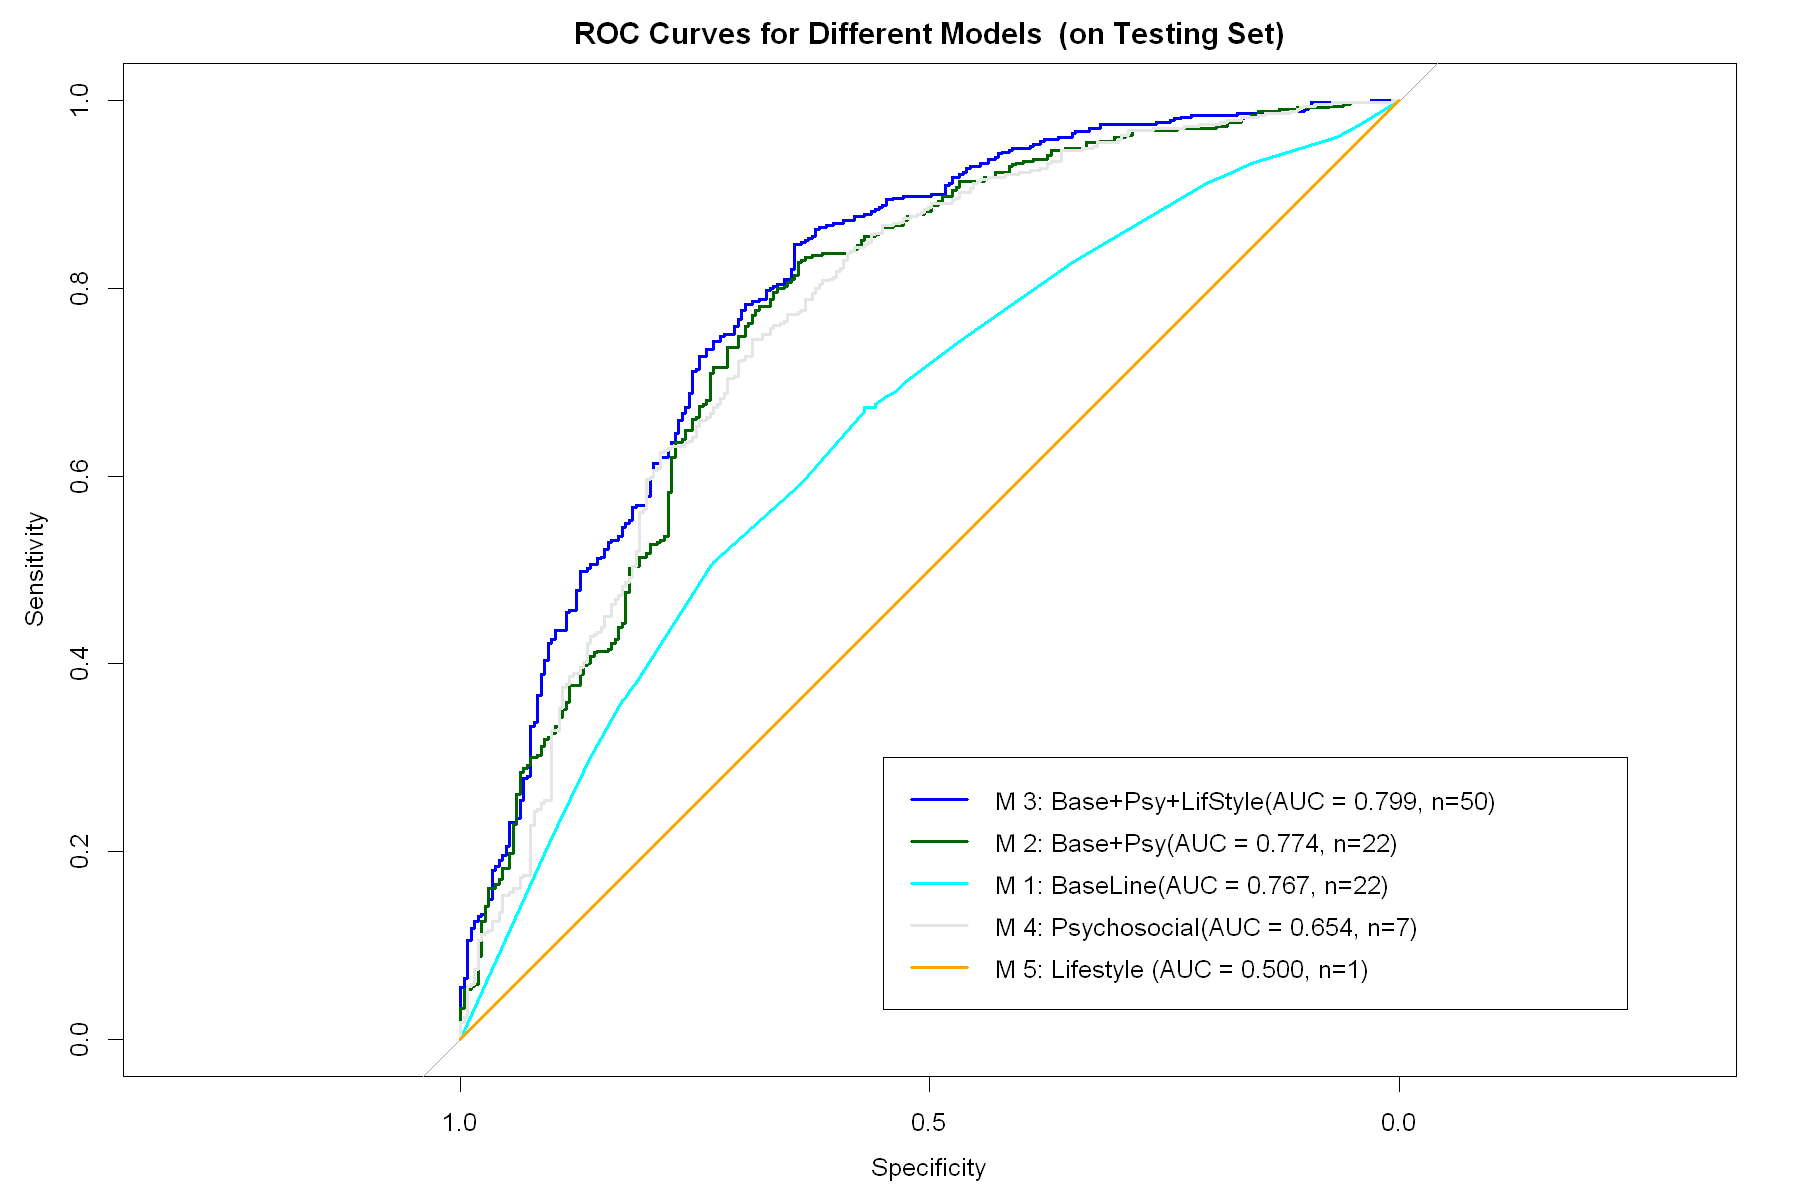

In [95]:
# Plot ROC Curves for All Models
roc_model1 <- metrics_model1$roc_curve
roc_model2 <- metrics_model2$roc_curve
roc_model3 <- metrics_model3$roc_curve
roc_model4 <- metrics_model4$roc_curve
roc_model5 <- metrics_model5$roc_curve

# ROC plot
# Prepare legend labels with model names and AUC values
    legend_labels <- c(
        paste0("M 3: Base+Psy+LifStyle(AUC = ", sprintf("%.3f", auc(roc_model3)), ", n=",len_model3, ")"),
        paste0("M 2: Base+Psy(AUC = ", sprintf("%.3f", auc(roc_model2)),  ", n=",len_model2,")"),
        paste0("M 1: BaseLine(AUC = ", sprintf("%.3f", auc(roc_model1)),  ", n=",len_model1,")"),
        paste0("M 4: Psychosocial(AUC = ", sprintf("%.3f", auc(roc_model4)),  ", n=",len_model4,")"),
        paste0("M 5: Lifestyle (AUC = ", sprintf("%.3f", auc(roc_model5)),  ", n=",len_model5,")")
    )
options(repr.plot.width=12, repr.plot.height=8)
# Create ROC plot
plot(roc_model3, col = "blue", main = "ROC Curves for Different Models  (on Testing Set)")
plot(roc_model2, col = "darkgreen", add = TRUE)
plot(roc_model4, col = "cyan", add = TRUE)
plot(roc_model1, col = "gray90", add = TRUE)
plot(roc_model5, col = "orange", add = TRUE)
    
# Add legend
legend(x = 0.55, y = 0.3, 
        legend = legend_labels,
        col = c("blue", "darkgreen", "cyan", "gray90", "orange"),
        lwd = 2)
    

In [96]:
# Create a results table
results_table <- data.frame(
    Model = c("Model 1: BaseLine", 
              "Model 2: BaseLine +Psychosocial", 
              "Model 3: BaseLine+P+Lifestyle", 
              "Model 4: Psychosocial", 
              "Model 5: Lifestyle"),
  
  Accuracy = round(c(
    metrics_model1$accuracy,
    metrics_model2$accuracy,
    metrics_model3$accuracy,
    metrics_model4$accuracy,
    metrics_model5$accuracy
  ), 3),
  
  AUC = round(c(
    metrics_model1$auc,
    metrics_model2$auc,
    metrics_model3$auc,
    metrics_model4$auc,
    metrics_model5$auc
  ), 3),
  
  `AUC (95% CI)` = c(
    paste0("[", round(metrics_model1$auc - result1$margin, 3), " - ", round(metrics_model1$auc + result1$margin, 3), "]"),
    paste0("[", round(metrics_model2$auc - result2$margin, 3), " - ", round(metrics_model2$auc + result2$margin, 3), "]"),
    paste0("[", round(metrics_model3$auc - result3$margin, 3), " - ", round(metrics_model3$auc + result3$margin, 3), "]"),
    paste0("[", round(metrics_model4$auc - result4$margin, 3), " - ", round(metrics_model4$auc + result4$margin, 3), "]"),
    paste0("[", round(metrics_model5$auc - result5$margin, 3), " - ", round(metrics_model5$auc + result5$margin, 3), "]")
  ),
    Sensitivity = c(metrics_model1$metrics[1], metrics_model2$metrics[1],
                    metrics_model3$metrics[1],metrics_model4$metrics[1],
                   metrics_model5$metrics[1]),
    
    Specificity = c(metrics_model1$metrics[2], metrics_model2$metrics[2],
                    metrics_model3$metrics[2], metrics_model4$metrics[2],
                    metrics_model5$metrics[2]),
    
    PPV = c(metrics_model1$metrics[3], metrics_model2$metrics[3],
            metrics_model3$metrics[3], metrics_model4$metrics[3],
           metrics_model5$metrics[3]),
    
    NPV = c(metrics_model1$metrics[4], metrics_model2$metrics[4],
            metrics_model3$metrics[4],metrics_model4$metrics[4],
            metrics_model5$metrics[4])
)

# Print the results table

IRdisplay::display(results_table)

Model,Accuracy,AUC,AUC..95..CI.,Sensitivity,Specificity,PPV,NPV
<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Model 1: BaseLine,0.726,0.767,[0.726 - 0.809],0.7450980,0.6891386,0.8207343,0.5859873
Model 2: BaseLine +Psychosocial,0.763,0.774,[0.746 - 0.802],0.8274510,0.6404494,0.8146718,0.6602317
Model 3: BaseLine+P+Lifestyle,0.777,0.799,[0.766 - 0.833],0.8470588,0.6441948,0.8197343,0.6880000
Model 4: Psychosocial,0.637,0.654,[0.619 - 0.689],0.6725490,0.5692884,0.7489083,0.4764890
Model 5: Lifestyle,0.499,0.500,[0.5 - 0.5],0.5000000,0.4981273,0.6555270,0.3427835


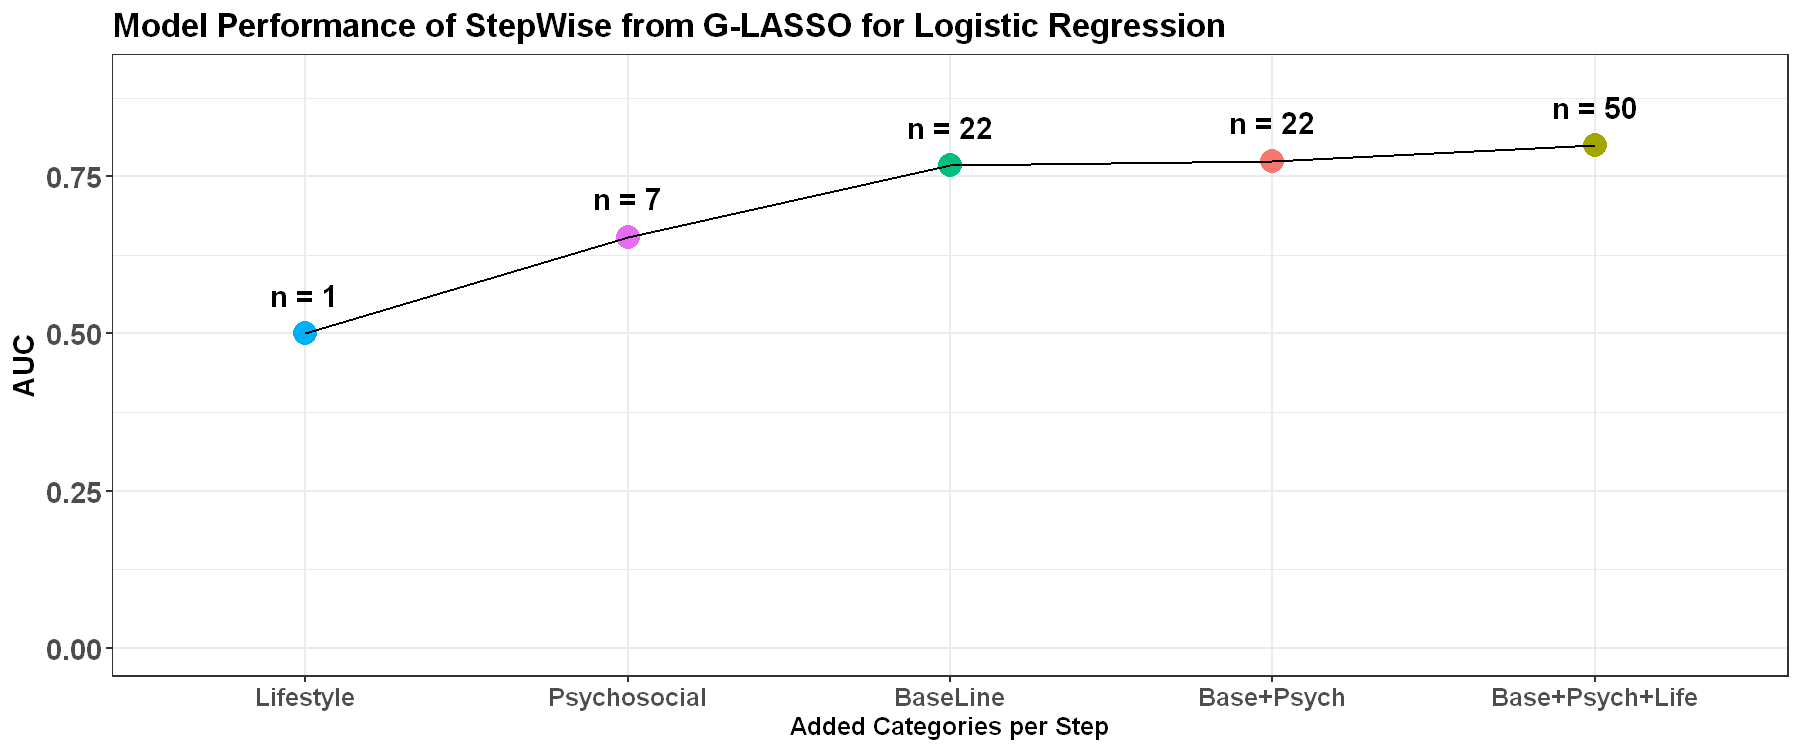

In [97]:
options(repr.plot.width=12, repr.plot.height=5)
# data frame for models importance
variable_importance <- data.frame(
  Variable = c("BaseLine", "Base+Psych", "Base+Psych+Life", 
               "Psychosocial", "Lifestyle"),
  auc_values = c(metrics_model1$auc, metrics_model2$auc, 
                 metrics_model3$auc, metrics_model4$auc,
                metrics_model5$auc),
  n_vars = c(len_model1, len_model2, len_model3, len_model4, len_model5)
)

# Create Figure : Variable Importance Plot
ggplot(variable_importance, aes(x = reorder(Variable, auc_values), y = auc_values)) +
  geom_point(aes(color = Variable), size = 5) +
  geom_line(group = 12) +
  geom_text(aes(label = paste0("n = ", n_vars)), 
            vjust = -1.2, size = 5, fontface = "bold") +  # Adjust `vjust` as needed
    ylim(0, .9) +  # Set Y-axis from 0 to 1
  labs(title = "Model Performance of StepWise from G-LASSO for Logistic Regression",
       x = "Added Categories per Step",
       y = "AUC") +
  theme_bw() +
  theme(
    legend.position = "none",
    plot.title = element_text(size = 16, face = "bold"),
    axis.title.x = element_text(size = 12, face = "bold"),
    axis.title.y = element_text(size = 14, face = "bold"),
    axis.text.x = element_text(size = 12, face = "bold"),
    axis.text.y = element_text(size = 14, face = "bold")
  )
